# Калибровка моделей PD: сравнение методов с акцентом на сплайн-калибровку

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from IPython.display import display
from scipy.stats import norm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from data.generate_data import (
    PORTFOLIO_RATING_ORDER,
    PORTFOLIO_RATING_PD_BOUNDS,
    generate_credit_data,
    get_oot_split,
    get_rating_portfolio_config,
    portfolio_summary,
)
from src.calibrators import get_all_calibrators
from src.metrics import (
    brier_score,
    bootstrap_ci,
    discrimination_metrics,
    fixed_bin_table,
    get_calibration_curve,
    summary_metrics,
)
from src.capital import IRBAssumptions, compare_irb_capital_by_method, calculate_irb_capital
from src.portfolio import (
    MASTER_SCALE_RATINGS,
    assign_master_scale_ratings,
    master_scale_bounds_table,
    method_master_scale_distribution,
    rating_scale_capital_by_rating,
    compare_methods_by_historical_panel,
    compare_methods_by_rating_master_scale,
    historical_portfolio_panel,
    method_portfolio_summary,
    portfolio_average_pd,
    rating_scale_capital,
    summarize_rating_scale,
    validate_common_rating_structure,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]
RANDOM_STATE = 42

print("Библиотеки и проектные модули загружены.")

Библиотеки и проектные модули загружены.


## 1. Постановка исследования и критерии сравнения

В рамках **Basel III / IRB-подхода** калибровка PD нужна не только для того, чтобы прогнозные вероятности совпадали с наблюдаемыми дефолтами по бинам риска, но и для того, чтобы итоговая оценка кредитного риска не искажала **резервы, RWA и требуемый капитал**. Поэтому в работе сравниваются не только графики калибровки, но и прикладной эффект от того, как каждый метод перераспределяет PD по шкале риска.

В исследовании сопоставляются шесть вариантов оценки PD на одной и той же базовой модели: **RF без калибровки**, **логит-калибровка**, **изотоническая регрессия**, **бета-калибровка**, **сплайн-калибровка** и **французский сплайн-калибровка**. Под сплайн-калибровкой понимается **монотонный гладкий сплайн**. Под **французским сплайном** понимается двухшаговая схема по мотивам подхода Banque de France / ICAS: сначала исходные PD калибруются логит-моделью, а затем логит-калиброванные PD дополнительно сглаживаются сплайном.

**Цель исследования** — определить, какой способ калибровки даёт наиболее обоснованное распределение PD по всей шкале риска и как это отражается на прикладном результате: величине **Reserves**, **RWA**, **требуемого капитала при H1 = 8%** и **экономии капитала относительно сырых PD**.

**Критерии сравнения** разделены на две группы:
- **статистические**: Brier Score, Log-Loss, ECE, HL p-value, а также визуальная согласованность PD с фактическими дефолтами по reliability-diagram и по фиксированным бинам `[0.0–0.1], …, [0.9–1.0]`;
- **прикладные**: итоговые **Reserves**, **имплицитный RWA**, **требуемый капитал при H1 = 8%**, **экономия капитала относительно сырых PD** и уровень **H1**, если сохранить капитал, достаточный для сырых PD.

Для сопоставимости прикладной части принимаются фиксированные допущения: **EAD = 1 000 000** для каждого наблюдения и **LGD = 40%**. Поэтому различия в итоговом капитале интерпретируются как эффект именно от выбора метода калибровки PD.

## 2. Данные: синтетический кредитный портфель

Portfolio scenario: stress
Rating mix target: {'A': 0.03, 'B': 0.36, 'C': 0.41, 'D': 0.16, 'E': 0.04}
Years: (2020, 2021, 2022, 2023, 2024)



,rating,pd_lower,pd_upper,pd_representative
0,A,0.05%,0.10%,0.07%
1,B,0.10%,0.65%,0.35%
2,C,0.65%,2.91%,1.78%
3,D,2.91%,26.00%,9.50%
4,E,26.00%,100.00%,40.00%


Датасет: 40,000 строк | 13 столбцов
Общая доля дефолтов: 4.79%
Средняя истинная PD в синтетике: 4.79%

Распределение истинной PD в портфеле:
min     0.05%
50%     1.29%
90%    13.69%
95%    22.38%
99%    62.36%
max    99.95%
Name: true_pd, dtype: str

Рейтинговая структура синтетического портфеля:
        наблюдений доля_дефолтов средняя_true_pd
rating                                          
A             1209         0.00%           0.08%
B            14259         0.47%           0.38%
C            16555         1.75%           1.79%
D             6370        11.65%          11.89%
E             1607        50.90%          50.29%

Дефолты по годам выдачи:
                  всего  дефолтов   доля
origination_year                        
2020               7100       348  4.90%
2021               7570       378  4.99%
2022               8079       398  4.93%
2023               8475       377  4.45%
2024               8776       415  4.73%


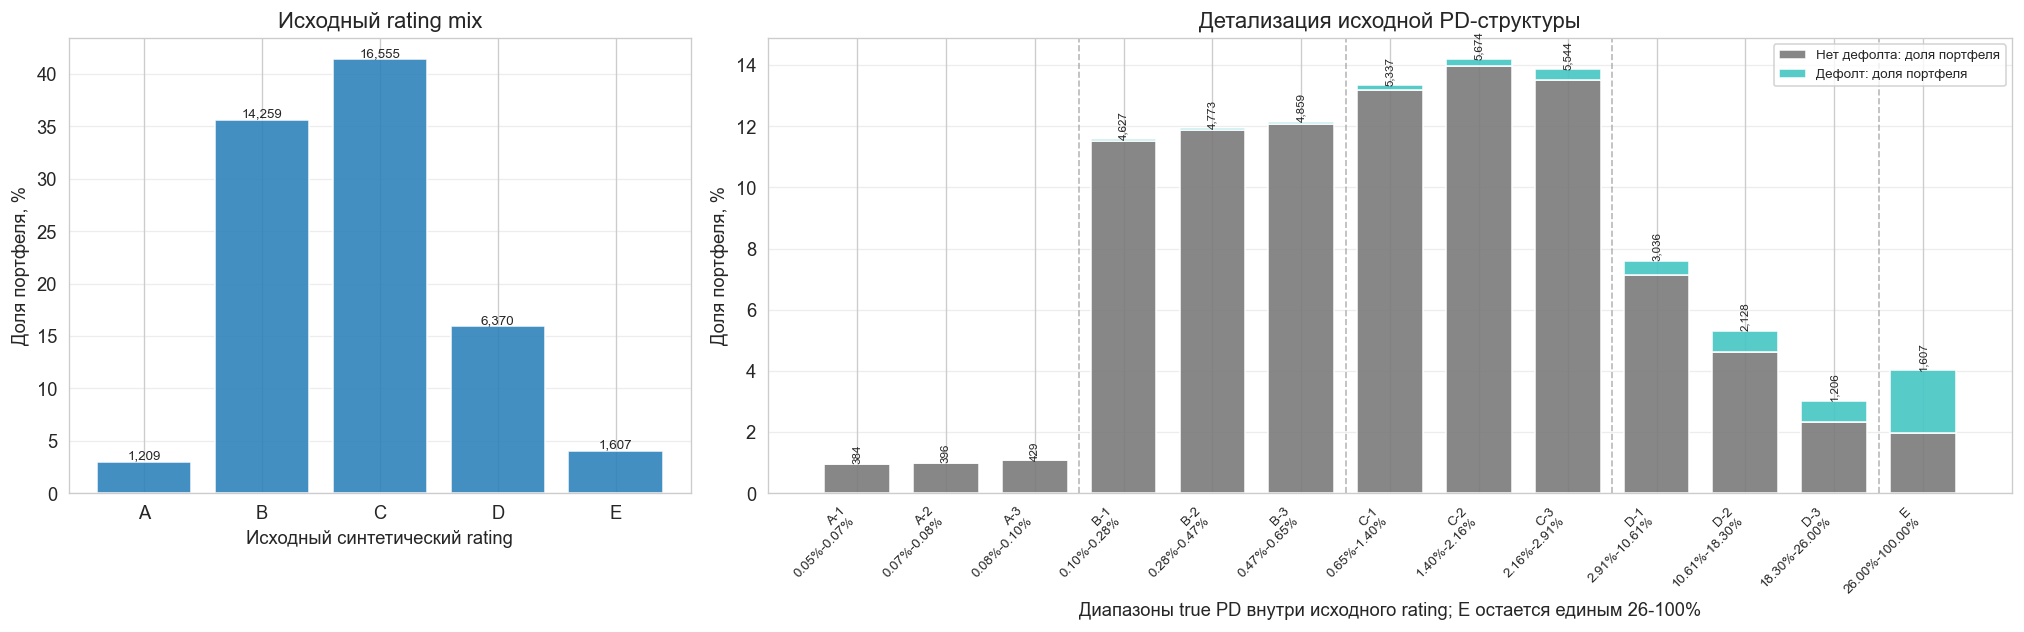

,source_rating,source_pd_band,band_left,band_right,n_assets,asset_share,bad_rate,avg_true_pd
0,A,A-1,0.05%,0.07%,384,0.96%,0.00%,0.06%
1,A,A-2,0.07%,0.08%,396,0.99%,0.00%,0.08%
2,A,A-3,0.08%,0.10%,429,1.07%,0.00%,0.09%
3,B,B-1,0.10%,0.28%,4627,11.57%,0.35%,0.19%
4,B,B-2,0.28%,0.47%,4773,11.93%,0.48%,0.37%
5,B,B-3,0.47%,0.65%,4859,12.15%,0.58%,0.56%
6,C,C-1,0.65%,1.40%,5337,13.34%,1.11%,1.04%
7,C,C-2,1.40%,2.16%,5674,14.19%,1.55%,1.78%
8,C,C-3,2.16%,2.91%,5544,13.86%,2.56%,2.53%
9,D,D-1,2.91%,10.61%,3036,7.59%,6.16%,6.47%


,credit_score,ltv,dti,employment_years,loan_amount,loan_term,num_delinquencies,loan_purpose
count,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00
mean,621.44,0.42,0.32,4.43,231.33,40.88,1.29,1.03
std,89.38,0.17,0.14,2.80,185.04,19.96,1.29,0.87
min,300.00,0.01,0.01,0.00,10.50,12.00,0.00,0.00
25%,562.00,0.30,0.22,2.30,126.40,24.00,0.00,0.00
50%,627.00,0.42,0.31,4.30,184.70,36.00,1.00,1.00
75%,689.00,0.54,0.42,6.30,275.30,48.00,2.00,2.00
max,850.00,1.00,0.93,17.70,4595.40,84.00,11.00,2.00


In [2]:
portfolio_config = get_rating_portfolio_config("stress")
df = generate_credit_data(random_state=RANDOM_STATE, portfolio=portfolio_config.name)

print(f"Portfolio scenario: {portfolio_config.name}")
print(f"Rating mix target: {portfolio_config.rating_mix}")
print(f"Years: {portfolio_config.years}\n")

rating_bounds = pd.DataFrame([
    {
        "rating": rating,
        "pd_lower": PORTFOLIO_RATING_PD_BOUNDS[rating][0],
        "pd_upper": PORTFOLIO_RATING_PD_BOUNDS[rating][1],
        "pd_representative": PORTFOLIO_RATING_PD_BOUNDS[rating][2],
    }
    for rating in portfolio_config.rating_order
])
display(rating_bounds.style.format({"pd_lower": "{:.2%}", "pd_upper": "{:.2%}", "pd_representative": "{:.2%}"}))

print(f"Датасет: {df.shape[0]:,} строк | {df.shape[1]} столбцов")
print(f"Общая доля дефолтов: {df['default'].mean():.2%}")
print(f"Средняя истинная PD в синтетике: {df['true_pd'].mean():.2%}\n")

true_pd_stats = df["true_pd"].describe(percentiles=[0.50, 0.90, 0.95, 0.99])[["min", "50%", "90%", "95%", "99%", "max"]]
print("Распределение истинной PD в портфеле:")
print(true_pd_stats.map(lambda x: f"{x:.2%}"))

segment_stats = (
    df.groupby("rating", sort=False)
      .agg(наблюдений=("default", "count"), доля_дефолтов=("default", "mean"), средняя_true_pd=("true_pd", "mean"))
      .reindex(portfolio_config.rating_order)
)
segment_map = {rating: rating for rating in portfolio_config.rating_order}
segment_stats.index = segment_stats.index.map(segment_map)
segment_stats["доля_дефолтов"] = segment_stats["доля_дефолтов"].map("{:.2%}".format)
segment_stats["средняя_true_pd"] = segment_stats["средняя_true_pd"].map("{:.2%}".format)
print("\nРейтинговая структура синтетического портфеля:")
print(segment_stats)

by_year = df.groupby("origination_year")["default"].agg(всего="count", дефолтов="sum", доля="mean")
by_year["доля"] = by_year["доля"].map("{:.2%}".format)
print("\nДефолты по годам выдачи:")
print(by_year)


def source_rating_summary(
    frame,
    rating_col="rating",
    default_col="default",
    pd_col="true_pd",
    rating_order=PORTFOLIO_RATING_ORDER,
    bounds=PORTFOLIO_RATING_PD_BOUNDS,
):
    summary = (
        frame.groupby(rating_col, observed=False)
        .agg(
            n_assets=(pd_col, "size"),
            defaults=(default_col, "sum"),
            avg_true_pd=(pd_col, "mean"),
        )
        .reindex(rating_order)
        .reset_index()
        .rename(columns={rating_col: "source_rating"})
    )
    summary["n_assets"] = summary["n_assets"].fillna(0).astype(int)
    summary["defaults"] = summary["defaults"].fillna(0).astype(int)
    summary["asset_share"] = summary["n_assets"] / len(frame)
    summary["bad_rate"] = np.where(
        summary["n_assets"] > 0,
        summary["defaults"] / summary["n_assets"],
        np.nan,
    )
    summary["pd_lower"] = summary["source_rating"].map(lambda r: bounds[r][0])
    summary["pd_upper"] = summary["source_rating"].map(lambda r: bounds[r][1])
    summary["pd_representative"] = summary["source_rating"].map(lambda r: bounds[r][2])
    return summary


def source_pd_band_summary(
    frame,
    rating_col="rating",
    default_col="default",
    pd_col="true_pd",
    extra_mean_cols=(),
    rating_order=PORTFOLIO_RATING_ORDER,
    bounds=PORTFOLIO_RATING_PD_BOUNDS,
    n_subbands=3,
):
    rows = []
    for rating in rating_order:
        rating_frame = frame.loc[frame[rating_col] == rating].copy()
        lower, upper, _ = bounds[rating]
        if rating == "E":
            edges = np.array([lower, upper])
        else:
            edges = np.linspace(lower, upper, n_subbands + 1)
        labels = [
            f"{rating}" if rating == "E" else f"{rating}-{i + 1}"
            for i in range(len(edges) - 1)
        ]
        rating_frame["_source_pd_band"] = pd.cut(
            rating_frame[pd_col],
            bins=edges,
            labels=labels,
            include_lowest=True,
            right=True,
        )
        agg_spec = {
            "n_assets": (pd_col, "size"),
            "defaults": (default_col, "sum"),
            "avg_true_pd": (pd_col, "mean"),
        }
        for col in extra_mean_cols:
            agg_spec[f"avg_{col}"] = (col, "mean")
        detail = (
            rating_frame.groupby("_source_pd_band", observed=False)
            .agg(**agg_spec)
            .reindex(labels)
            .reset_index()
            .rename(columns={"_source_pd_band": "source_pd_band"})
        )
        detail["source_rating"] = rating
        detail["band_left"] = edges[:-1]
        detail["band_right"] = edges[1:]
        rows.append(detail)

    detail = pd.concat(rows, ignore_index=True)
    detail["n_assets"] = detail["n_assets"].fillna(0).astype(int)
    detail["defaults"] = detail["defaults"].fillna(0).astype(int)
    detail["non_defaults"] = detail["n_assets"] - detail["defaults"]
    detail["asset_share"] = detail["n_assets"] / len(frame)
    detail["default_portfolio_share"] = detail["defaults"] / len(frame)
    detail["non_default_portfolio_share"] = detail["non_defaults"] / len(frame)
    detail["bad_rate"] = np.where(
        detail["n_assets"] > 0,
        detail["defaults"] / detail["n_assets"],
        np.nan,
    )
    detail["band_label"] = (
        detail["source_pd_band"].astype(str)
        + "\n"
        + detail["band_left"].map("{:.2%}".format)
        + "-"
        + detail["band_right"].map("{:.2%}".format)
    )
    return detail


source_rating_mix = source_rating_summary(df, rating_order=portfolio_config.rating_order)
source_pd_detail = source_pd_band_summary(df, rating_order=portfolio_config.rating_order)

detail_reconciliation = (
    source_pd_detail.groupby("source_rating", observed=False)["n_assets"].sum()
    .reindex(portfolio_config.rating_order)
    .to_numpy()
)
if not np.array_equal(detail_reconciliation, source_rating_mix["n_assets"].to_numpy()):
    raise ValueError("Detailed source PD bands do not reconcile to the source rating mix.")

fig, axes = plt.subplots(1, 2, figsize=(17, 5.4), gridspec_kw={"width_ratios": [0.8, 1.6]})

ax = axes[0]
x = np.arange(len(source_rating_mix))
ax.bar(x, source_rating_mix["asset_share"] * 100, color="#2980b9", alpha=0.88)
for i, row in source_rating_mix.iterrows():
    ax.text(
        i,
        row["asset_share"] * 100,
        f'{int(row["n_assets"]):,}',
        ha="center",
        va="bottom",
        fontsize=8,
    )
ax.set_xticks(x)
ax.set_xticklabels(source_rating_mix["source_rating"])
ax.set_xlabel("Исходный синтетический rating")
ax.set_ylabel("Доля портфеля, %")
ax.set_title("Исходный rating mix")
ax.grid(axis="y", alpha=0.35)

ax = axes[1]
detail_x = np.arange(len(source_pd_detail))
ax.bar(
    detail_x,
    source_pd_detail["non_default_portfolio_share"] * 100,
    width=0.74,
    color="#7a7a7a",
    label="Нет дефолта: доля портфеля",
    alpha=0.90,
)
ax.bar(
    detail_x,
    source_pd_detail["default_portfolio_share"] * 100,
    width=0.74,
    bottom=source_pd_detail["non_default_portfolio_share"] * 100,
    color="#48c7c4",
    label="Дефолт: доля портфеля",
    alpha=0.92,
)
group_sizes = source_pd_detail.groupby("source_rating", sort=False).size().to_numpy()
for group_end in np.cumsum(group_sizes)[:-1] - 0.5:
    ax.axvline(group_end, color="gray", linestyle="--", lw=1.0, alpha=0.55)
for i, row in source_pd_detail.iterrows():
    if row["n_assets"] > 0:
        ax.text(
            i,
            row["asset_share"] * 100,
            f'{int(row["n_assets"]):,}',
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )
ax.set_xticks(detail_x)
ax.set_xticklabels(source_pd_detail["band_label"], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Диапазоны true PD внутри исходного rating; E остается единым 26-100%")
ax.set_ylabel("Доля портфеля, %")
ax.set_title("Детализация исходной PD-структуры")
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", alpha=0.35)

plt.tight_layout()
plt.show()

display(
    source_pd_detail[[
        "source_rating", "source_pd_band", "band_left", "band_right",
        "n_assets", "asset_share", "bad_rate", "avg_true_pd",
    ]]
    .style.format({
        "band_left": "{:.2%}",
        "band_right": "{:.2%}",
        "asset_share": "{:.2%}",
        "bad_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
    })
)

display(df.drop(columns=["default", "origination_year", "risk_segment", "true_pd"]).describe().round(2))


### Историческая структура портфеля по рейтингам

Здесь портфель не сводится к одной средней PD. Мы восстанавливаем его как `год выдачи × рейтинг`: количество наблюдений, доля рейтинга в портфеле, средняя PD, фактическая доля дефолтов и ожидаемое число дефолтов. Одна агрегированная PD выводится только как контрольный итог.


In [3]:
historical_panel_true = historical_portfolio_panel(df, pd_col="true_pd")
portfolio_avg_true_pd = portfolio_average_pd(df, pd_col="true_pd")

print(f"Агрегированная PD портфеля: {portfolio_avg_true_pd:.2%}")
print("Эта величина нужна только как итог; анализ ниже сохраняет структуру год × рейтинг.")

portfolio_view_cols = [
    "origination_year",
    "rating",
    "n_obs",
    "portfolio_count_share",
    "avg_pd",
    "observed_default_rate",
    "expected_defaults",
    "defaults",
    "calibration_ratio",
]
display(
    historical_panel_true[portfolio_view_cols]
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "avg_pd": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)


Агрегированная PD портфеля: 4.79%
Эта величина нужна только как итог; анализ ниже сохраняет структуру год × рейтинг.


,origination_year,rating,n_obs,portfolio_count_share,avg_pd,observed_default_rate,expected_defaults,defaults,calibration_ratio
0,2020,A,221,3.1%,0.08%,0.00%,0.17,0,0.00
1,2020,B,2490,35.1%,0.38%,0.56%,9.45,14,1.48
2,2020,C,2949,41.5%,1.80%,1.46%,53.07,43,0.81
3,2020,D,1145,16.1%,11.75%,11.88%,134.49,136,1.01
4,2020,E,295,4.2%,51.14%,52.54%,150.86,155,1.03
5,2021,A,248,3.3%,0.08%,0.00%,0.19,0,0.00
6,2021,B,2698,35.6%,0.38%,0.44%,10.22,12,1.17
7,2021,C,3129,41.3%,1.78%,1.79%,55.78,56,1.00
8,2021,D,1191,15.7%,11.97%,13.01%,142.53,155,1.09
9,2021,E,304,4.0%,51.80%,50.99%,157.48,155,0.98


### Проверка сценариев портфеля: normal vs stress

В проекте есть два режима генерации портфеля. Основной notebook дальше использует `stress`, потому что в нем хорошо заселена верхняя часть PD-шкалы и легче увидеть эффект калибровки на RWA. Но для банковской интерпретации полезно отдельно видеть, что `normal` портфель существует и дает более умеренную дефолтность.

In [4]:
scenario_rows = []
for scenario in ["normal", "stress"]:
    scenario_df = generate_credit_data(n_samples=40_000, random_state=RANDOM_STATE, portfolio=scenario)
    summary = portfolio_summary(scenario_df)
    scenario_rows.append({
        "scenario": scenario,
        "n_obs": summary["n_obs"],
        "default_rate": summary["default_rate"],
        "avg_true_pd": summary["avg_true_pd"],
        "p95_true_pd": summary["p95_true_pd"],
        "max_true_pd": summary["max_true_pd"],
    })

scenario_table = pd.DataFrame(scenario_rows).set_index("scenario")
display(
    scenario_table.style.format({
        "default_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
        "p95_true_pd": "{:.2%}",
        "max_true_pd": "{:.2%}",
    })
)

print("Дальше в notebook используется stress-сценарий, чтобы проверять калибровку не только в низких PD.")

,n_obs,default_rate,avg_true_pd,p95_true_pd,max_true_pd
scenario,,,,,
normal,40000,2.69%,2.72%,13.32%,99.91%
stress,40000,4.79%,4.79%,22.38%,99.95%


Дальше в notebook используется stress-сценарий, чтобы проверять калибровку не только в низких PD.


## 3. Экспериментальный протокол и схема выборок

В эксперименте используется **out-of-time схема**: модель и калибраторы настраиваются на одном историческом in-time периоде, а итоговое качество проверяется только на будущем OOT-портфеле.
- **Train + Calibration (2020-2023)** — общий in-time период: на нем обучается базовая RF-модель и на ее же in-time scores обучаются калибраторы;
- **Test OOT (2024)** — финальная оценка качества калибровки, капитального эффекта и рейтингового распределения на будущих данных.

Такой вариант соответствует текущей методологии проекта: мы не выделяем отдельный 2023 год под независимую calibration-выборку, потому что для этой задачи важнее использовать весь доступный in-time период для оценки RF и пост-калибровочной функции. При этом **test OOT не используется для настройки параметров калибраторов**: он остается только финальной проверкой.

In [5]:
X_train, X_calib, X_test, y_train, y_calib, y_test = get_oot_split(df)
split_years = sorted(df["origination_year"].unique())
train_calib_label = f"{split_years[0]}-{split_years[-2]}" if len(split_years[:-1]) > 1 else str(split_years[0])
test_label = str(split_years[-1])

print("Out-of-Time разбивка:")
print(f"  Train+Calibration ({train_calib_label}): {len(X_train):,} строк | дефолты: {y_train.mean():.2%}")
print(f"  Calibrator fit     ({train_calib_label}): {len(X_calib):,} строк | дефолты: {y_calib.mean():.2%}")
print(f"  Test OOT           ({test_label}): {len(X_test):,} строк | дефолты: {y_test.mean():.2%}")

Out-of-Time разбивка:
  Train+Calibration (2020-2023): 31,224 строк | дефолты: 4.81%
  Calibrator fit     (2020-2023): 31,224 строк | дефолты: 4.81%
  Test OOT           (2024): 8,776 строк | дефолты: 4.73%


## 4. Базовая модель и исходное качество некалиброванных PD

В этом блоке важно разделить две разные шкалы. Синтетический портфель уже содержит исходный рейтинг `A...E` и скрытую `true_pd`, по которой сгенерирован факт дефолта. Random Forest не получает ни `rating`, ни `true_pd` как признаки: он учится только по наблюдаемым характеристикам заемщика и факту дефолта, а затем выдает собственный сырой `predict_proba`. Поэтому RF не является механическим преобразованием `true_pd`; ниже `rating` и `true_pd` используются только как контрольная разметка, чтобы понять, насколько raw RF PD согласуется с исходной риск-структурой.


In [6]:
base_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
base_model.fit(X_train, y_train)

scores_calib = np.clip(base_model.predict_proba(X_calib)[:, 1], 1e-6, 1 - 1e-6)
scores_test  = np.clip(base_model.predict_proba(X_test)[:, 1], 1e-6, 1 - 1e-6)

print(f"Диапазон скоров RF на OOT: [{scores_test.min():.4f}, {scores_test.max():.4f}]")
print(f"Медиана скоров RF:         {np.median(scores_test):.4f}")
print(f"90 / 95 / 99 перцентили:   {np.quantile(scores_test, [0.90, 0.95, 0.99]).round(4)}")
print(f"Скоры > 0.5:               {(scores_test > 0.5).mean():.1%}")

Диапазон скоров RF на OOT: [0.0031, 0.8679]
Медиана скоров RF:         0.0165
90 / 95 / 99 перцентили:   [0.1107 0.257  0.4589]
Скоры > 0.5:               0.7%


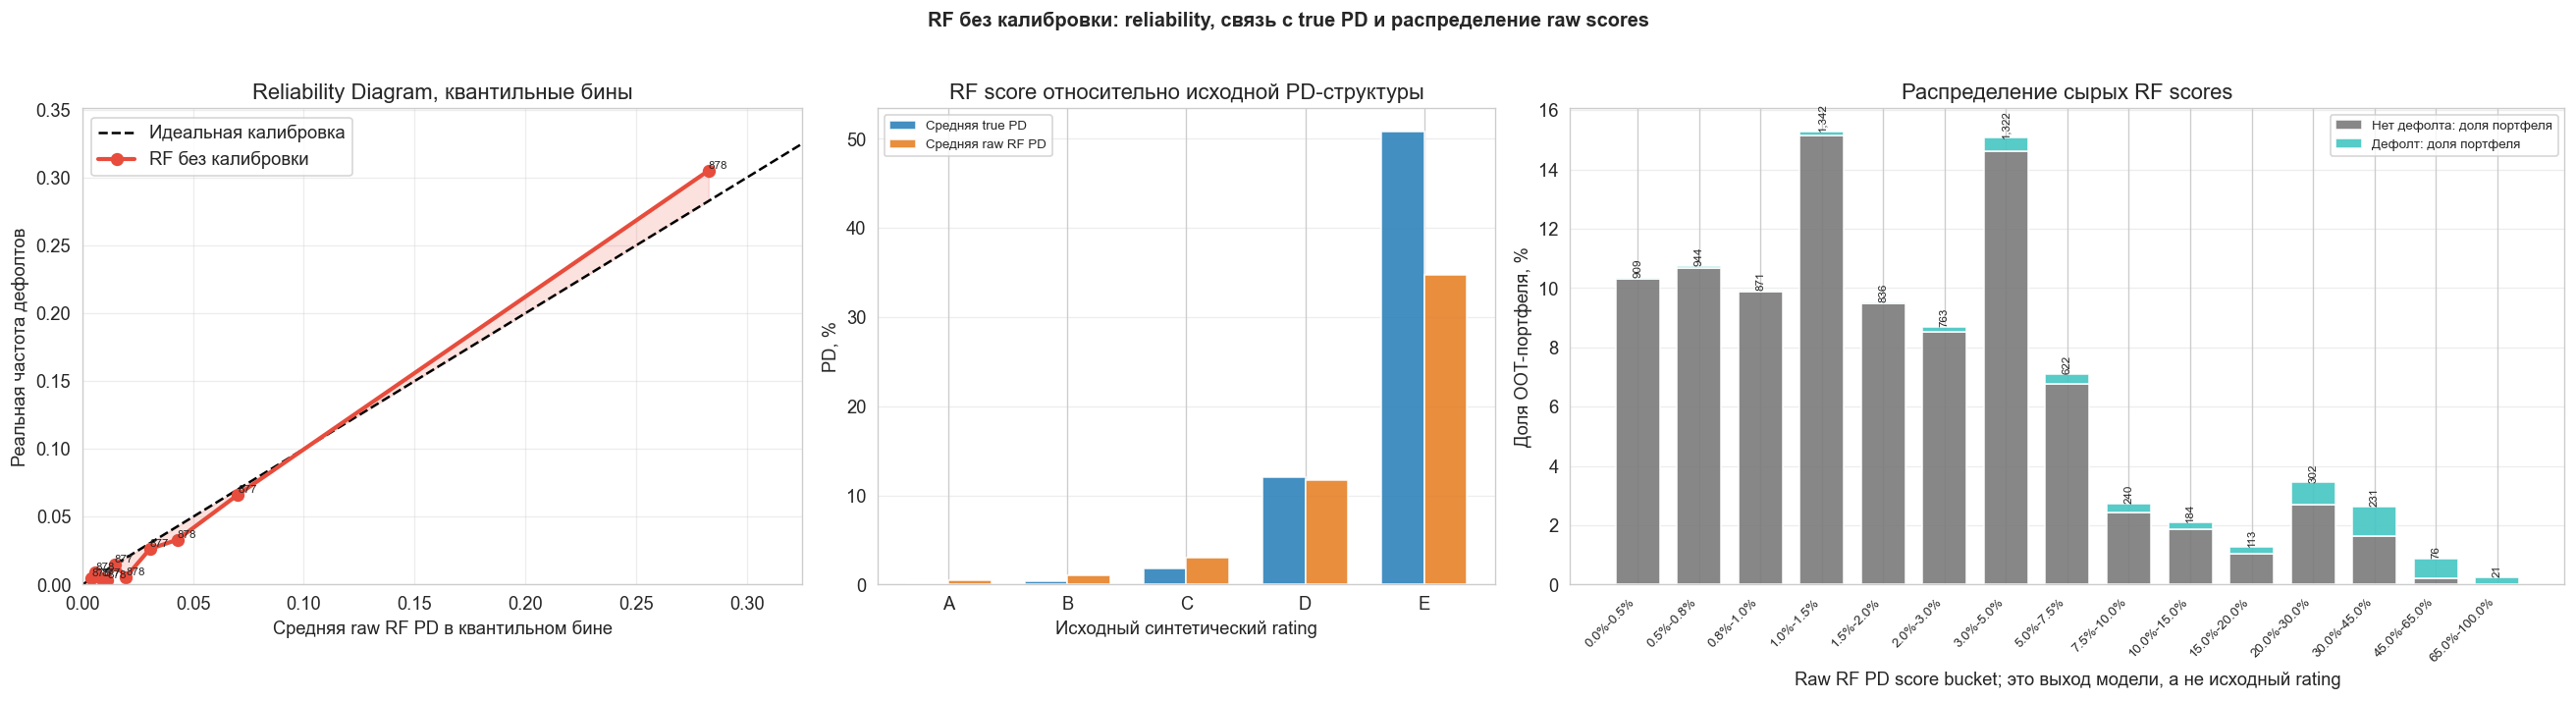

RF не получает rating/true_pd как признаки. Эти поля используются здесь только для диагностики качества raw predict_proba.
Средняя true PD на OOT: 4.83%
Средняя raw RF PD на OOT: 4.90%
Минимальная raw RF PD: 0.313%
Наблюдений с raw RF PD < 0.05%: 0
Наблюдений с raw RF PD < 0.50%: 909


In [7]:
raw_pd_edges = np.array([
    0.000, 0.005, 0.0075, 0.010, 0.015, 0.020, 0.030,
    0.050, 0.075, 0.100, 0.150, 0.200, 0.300, 0.450, 0.650, 1.000,
])

raw_score_frame = pd.DataFrame({
    "raw_pd": scores_test,
    "default": y_test.values,
    "source_rating": df.loc[y_test.index, "rating"].values,
    "true_pd": df.loc[y_test.index, "true_pd"].values,
}, index=y_test.index)
raw_score_frame["pd_bin"] = pd.cut(
    raw_score_frame["raw_pd"],
    bins=raw_pd_edges,
    include_lowest=True,
    right=True,
)

raw_bin_summary = (
    raw_score_frame.groupby("pd_bin", observed=False)
    .agg(
        n_assets=("raw_pd", "size"),
        defaults=("default", "sum"),
        raw_pd_min_actual=("raw_pd", "min"),
        raw_pd_max_actual=("raw_pd", "max"),
        avg_raw_pd=("raw_pd", "mean"),
        avg_true_pd=("true_pd", "mean"),
    )
    .reset_index()
)
raw_bin_summary["pd_left"] = raw_pd_edges[:-1]
raw_bin_summary["pd_right"] = raw_pd_edges[1:]
raw_bin_summary["pd_width"] = raw_bin_summary["pd_right"] - raw_bin_summary["pd_left"]
raw_bin_summary["non_defaults"] = raw_bin_summary["n_assets"] - raw_bin_summary["defaults"]
raw_bin_summary["bad_rate"] = np.where(
    raw_bin_summary["n_assets"] > 0,
    raw_bin_summary["defaults"] / raw_bin_summary["n_assets"],
    np.nan,
)
raw_bin_summary["asset_share"] = raw_bin_summary["n_assets"] / len(raw_score_frame)
raw_bin_summary["default_portfolio_share"] = raw_bin_summary["defaults"] / len(raw_score_frame)
raw_bin_summary["non_default_portfolio_share"] = raw_bin_summary["non_defaults"] / len(raw_score_frame)

raw_rating_summary = source_rating_summary(
    raw_score_frame,
    rating_col="source_rating",
    default_col="default",
    pd_col="true_pd",
    rating_order=portfolio_config.rating_order,
)
raw_rating_summary["avg_raw_pd"] = (
    raw_score_frame.groupby("source_rating", observed=False)["raw_pd"]
    .mean()
    .reindex(portfolio_config.rating_order)
    .to_numpy()
)

oot_source_pd_detail = source_pd_band_summary(
    raw_score_frame,
    rating_col="source_rating",
    default_col="default",
    pd_col="true_pd",
    extra_mean_cols=("raw_pd",),
    rating_order=portfolio_config.rating_order,
)

rf_reliability = raw_score_frame.copy()
rf_reliability["quantile_bin"] = pd.qcut(
    rf_reliability["raw_pd"],
    q=10,
    duplicates="drop",
)
rf_reliability_summary = (
    rf_reliability.groupby("quantile_bin", observed=True)
    .agg(
        n_assets=("raw_pd", "size"),
        mean_pred=("raw_pd", "mean"),
        observed_default_rate=("default", "mean"),
        avg_true_pd=("true_pd", "mean"),
    )
    .reset_index(drop=True)
)
rf_reliability_summary["abs_calibration_gap"] = (
    rf_reliability_summary["observed_default_rate"]
    - rf_reliability_summary["mean_pred"]
).abs()

rating_x = np.arange(len(raw_rating_summary["source_rating"]))
bin_labels = [
    f"{left:.1%}-{right:.1%}"
    for left, right in zip(raw_pd_edges[:-1], raw_pd_edges[1:])
]
bucket_x = np.arange(len(raw_bin_summary))

fig, axes = plt.subplots(
    1, 3, figsize=(22, 5.8), gridspec_kw={"width_ratios": [1.05, 0.9, 1.45]}
)

ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Идеальная калибровка")
ax.plot(
    rf_reliability_summary["mean_pred"],
    rf_reliability_summary["observed_default_rate"],
    "o-",
    color=COLORS[0],
    lw=2.5,
    ms=7,
    label="RF без калибровки",
)
ax.fill_between(
    rf_reliability_summary["mean_pred"],
    rf_reliability_summary["mean_pred"],
    rf_reliability_summary["observed_default_rate"],
    alpha=0.16,
    color=COLORS[0],
)
for _, row in rf_reliability_summary.iterrows():
    ax.text(
        row["mean_pred"],
        row["observed_default_rate"],
        f'{int(row["n_assets"]):,}',
        fontsize=7,
        ha="left",
        va="bottom",
    )
ax.set_xlim(0, max(0.10, min(1.0, rf_reliability_summary["mean_pred"].max() * 1.15)))
ax.set_ylim(0, max(0.10, min(1.0, rf_reliability_summary["observed_default_rate"].max() * 1.15)))
ax.set_xlabel("Средняя raw RF PD в квантильном бине")
ax.set_ylabel("Реальная частота дефолтов")
ax.set_title("Reliability Diagram, квантильные бины")
ax.legend(loc="upper left")
ax.grid(alpha=0.35)

ax = axes[1]
width = 0.36
ax.bar(
    rating_x - width / 2,
    raw_rating_summary["avg_true_pd"] * 100,
    width=width,
    color="#2980b9",
    alpha=0.88,
    label="Средняя true PD",
)
ax.bar(
    rating_x + width / 2,
    raw_rating_summary["avg_raw_pd"] * 100,
    width=width,
    color="#e67e22",
    alpha=0.88,
    label="Средняя raw RF PD",
)
ax.set_xticks(rating_x)
ax.set_xticklabels(raw_rating_summary["source_rating"])
ax.set_xlabel("Исходный синтетический rating")
ax.set_ylabel("PD, %")
ax.set_title("RF score относительно исходной PD-структуры")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.35)

ax = axes[2]
ax.bar(
    bucket_x,
    raw_bin_summary["non_default_portfolio_share"] * 100,
    width=0.72,
    color="#7a7a7a",
    label="Нет дефолта: доля портфеля",
    alpha=0.90,
)
ax.bar(
    bucket_x,
    raw_bin_summary["default_portfolio_share"] * 100,
    width=0.72,
    bottom=raw_bin_summary["non_default_portfolio_share"] * 100,
    color="#48c7c4",
    label="Дефолт: доля портфеля",
    alpha=0.92,
)
for i, row in raw_bin_summary.iterrows():
    if row["n_assets"] > 0:
        ax.text(
            i,
            row["asset_share"] * 100,
            f'{int(row["n_assets"]):,}',
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )
ax.set_xticks(bucket_x)
ax.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Raw RF PD score bucket; это выход модели, а не исходный rating")
ax.set_ylabel("Доля OOT-портфеля, %")
ax.set_title("Распределение сырых RF scores")
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", alpha=0.35)

plt.suptitle(
    "RF без калибровки: reliability, связь с true PD и распределение raw scores",
    fontsize=12, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

print("RF не получает rating/true_pd как признаки. Эти поля используются здесь только для диагностики качества raw predict_proba.")
print(f"Средняя true PD на OOT: {raw_score_frame['true_pd'].mean():.2%}")
print(f"Средняя raw RF PD на OOT: {raw_score_frame['raw_pd'].mean():.2%}")
print(f"Минимальная raw RF PD: {raw_score_frame['raw_pd'].min():.3%}")
print(f"Наблюдений с raw RF PD < 0.05%: {(raw_score_frame['raw_pd'] < 0.0005).sum():,}")
print(f"Наблюдений с raw RF PD < 0.50%: {(raw_score_frame['raw_pd'] < 0.0050).sum():,}")


Таблицы ниже разделяют исходную структуру OOT-портфеля и выход модели. В `raw RF score buckets` добавлены фактические минимум/максимум raw PD внутри bucket: это важно, потому что bucket `0.0%-0.5%` не означает, что все наблюдения имеют PD ниже `0.05%`; это широкий интервал до половины процента.


In [8]:
rating_display_cols = [
    "source_rating", "pd_lower", "pd_upper", "pd_representative",
    "n_assets", "asset_share", "bad_rate", "avg_true_pd", "avg_raw_pd",
]
display(
    raw_rating_summary[rating_display_cols]
    .style.format({
        "pd_lower": "{:.3%}",
        "pd_upper": "{:.3%}",
        "pd_representative": "{:.3%}",
        "asset_share": "{:.2%}",
        "bad_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
        "avg_raw_pd": "{:.2%}",
    })
)

detail_display_cols = [
    "source_rating", "source_pd_band", "band_left", "band_right",
    "n_assets", "asset_share", "bad_rate", "avg_true_pd", "avg_raw_pd",
]
display(
    oot_source_pd_detail[detail_display_cols]
    .style.format({
        "band_left": "{:.2%}",
        "band_right": "{:.2%}",
        "asset_share": "{:.2%}",
        "bad_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
        "avg_raw_pd": "{:.2%}",
    })
)

display(
    rf_reliability_summary.style.format({
        "mean_pred": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
        "abs_calibration_gap": "{:.2%}",
    })
)

raw_bucket_display_cols = [
    "pd_left", "pd_right", "pd_width", "n_assets", "defaults",
    "bad_rate", "raw_pd_min_actual", "raw_pd_max_actual",
    "avg_true_pd", "avg_raw_pd", "asset_share",
]
display(
    raw_bin_summary[raw_bucket_display_cols].style.format({
        "pd_left": "{:.3%}",
        "pd_right": "{:.3%}",
        "pd_width": "{:.3%}",
        "bad_rate": "{:.2%}",
        "raw_pd_min_actual": "{:.3%}",
        "raw_pd_max_actual": "{:.3%}",
        "avg_true_pd": "{:.2%}",
        "avg_raw_pd": "{:.2%}",
        "asset_share": "{:.2%}",
    })
)


,source_rating,pd_lower,pd_upper,pd_representative,n_assets,asset_share,bad_rate,avg_true_pd,avg_raw_pd
0,A,0.050%,0.100%,0.075%,257,2.93%,0.00%,0.08%,0.53%
1,B,0.100%,0.650%,0.350%,3134,35.71%,0.41%,0.38%,1.00%
2,C,0.650%,2.910%,1.780%,3619,41.24%,1.80%,1.80%,3.05%
3,D,2.910%,26.000%,9.500%,1421,16.19%,10.98%,12.04%,11.75%
4,E,26.000%,100.000%,40.000%,345,3.93%,52.46%,50.87%,34.77%


,source_rating,source_pd_band,band_left,band_right,n_assets,asset_share,bad_rate,avg_true_pd,avg_raw_pd
0,A,A-1,0.05%,0.07%,80,0.91%,0.00%,0.06%,0.41%
1,A,A-2,0.07%,0.08%,82,0.93%,0.00%,0.07%,0.47%
2,A,A-3,0.08%,0.10%,95,1.08%,0.00%,0.09%,0.67%
3,B,B-1,0.10%,0.28%,991,11.29%,0.50%,0.20%,0.51%
4,B,B-2,0.28%,0.47%,1023,11.66%,0.59%,0.37%,0.81%
5,B,B-3,0.47%,0.65%,1120,12.76%,0.18%,0.56%,1.62%
6,C,C-1,0.65%,1.40%,1157,13.18%,1.30%,1.04%,1.11%
7,C,C-2,1.40%,2.16%,1233,14.05%,1.30%,1.79%,2.45%
8,C,C-3,2.16%,2.91%,1229,14.00%,2.77%,2.53%,5.49%
9,D,D-1,2.91%,10.61%,664,7.57%,6.02%,6.44%,4.62%


,n_assets,mean_pred,observed_default_rate,avg_true_pd,abs_calibration_gap
0,878,0.41%,0.46%,0.19%,0.04%
1,878,0.60%,0.91%,0.41%,0.31%
2,877,0.85%,0.46%,0.61%,0.39%
3,878,1.11%,0.34%,0.79%,0.77%
4,877,1.45%,1.48%,1.10%,0.03%
5,878,1.97%,0.57%,1.70%,1.40%
6,877,3.05%,2.62%,2.62%,0.42%
7,878,4.28%,3.30%,3.82%,0.98%
8,877,7.01%,6.61%,7.35%,0.40%
9,878,28.28%,30.52%,29.70%,2.24%


,pd_left,pd_right,pd_width,n_assets,defaults,bad_rate,raw_pd_min_actual,raw_pd_max_actual,avg_true_pd,avg_raw_pd,asset_share
0,0.000%,0.500%,0.500%,909,4,0.44%,0.313%,0.500%,0.20%,0.42%,10.36%
1,0.500%,0.750%,0.250%,944,8,0.85%,0.500%,0.750%,0.43%,0.61%,10.76%
2,0.750%,1.000%,0.250%,871,4,0.46%,0.750%,1.000%,0.63%,0.87%,9.92%
3,1.000%,1.500%,0.500%,1342,12,0.89%,1.000%,1.500%,0.92%,1.23%,15.29%
4,1.500%,2.000%,0.500%,836,5,0.60%,1.500%,2.000%,1.39%,1.73%,9.53%
5,2.000%,3.000%,1.000%,763,16,2.10%,2.003%,2.998%,2.20%,2.44%,8.69%
6,3.000%,5.000%,2.000%,1322,40,3.03%,3.001%,4.996%,3.44%,3.93%,15.06%
7,5.000%,7.500%,2.500%,622,28,4.50%,5.001%,7.499%,6.06%,6.03%,7.09%
8,7.500%,10.000%,2.500%,240,27,11.25%,7.503%,9.986%,9.27%,8.57%,2.73%
9,10.000%,15.000%,5.000%,184,21,11.41%,10.008%,14.984%,12.97%,12.22%,2.10%


Random Forest здесь не «берет PD из синтетического портфеля» напрямую. В `get_oot_split` из признаков исключены `rating`, `risk_segment` и `true_pd`, поэтому модель видит только кредитные характеристики и факт дефолта. Сырые `predict_proba` должны быть близки к риск-структуре, если признаки хорошо восстанавливают скрытую PD, но это отдельная модельная оценка, а не исходная шкала.

Почему RF может давать PD вне исходных rating-границ: дерево делит заемщиков по признакам, а вероятность в листе равна доле дефолтов среди похожих наблюдений; лес усредняет такие доли по многим деревьям. Никакого ограничения `A >= 0.05%` или `E <= 100%` внутри RF нет. При этом средняя raw RF PD на всем OOT-портфеле должна быть сопоставима со средней `true_pd`, а проверять качество надо по reliability / Brier / Log-Loss, а не по одному распределению buckets.

Ломаная reliability-кривая на фиксированных bins часто появляется из-за редких высоких PD buckets: если в bucket попали десятки наблюдений, несколько дефолтов резко двигают фактическую частоту. Поэтому в этом разделе используется квантильная reliability-диагностика с примерно равным числом наблюдений в каждом бине; фиксированные buckets оставлены только как распределение raw scores.


## 5. Обучение и проверка PD-калибраторов

Все калибраторы получают на вход одну и ту же величину: сырую PD базовой RF-модели (`scores_calib`). Целевая переменная для настройки - фактический дефолт на in-time периоде (`y_calib`). После обучения каждый калибратор применяется только к `scores_test`, то есть к будущему OOT-портфелю. Ни `true_pd`, ни `rating` не используются в калибровке; они остаются только диагностической разметкой синтетики.


In [9]:
calibrators = get_all_calibrators()
calibrated_probs = {}
calibrated_probs_calib = {}

score_grid = np.linspace(
    max(1e-6, float(np.quantile(scores_calib, 0.001))),
    min(1.0 - 1e-6, float(np.quantile(scores_calib, 0.999))),
    500,
)

calibration_audit_rows = []
for name, cal in calibrators.items():
    cal.fit(scores_calib, y_calib.values)
    pred_calib = np.clip(cal.predict(scores_calib), 1e-6, 1 - 1e-6)
    pred_test = np.clip(cal.predict(scores_test), 1e-6, 1 - 1e-6)
    grid_pred = np.clip(cal.predict(score_grid), 1e-6, 1 - 1e-6)

    calibrated_probs_calib[name] = pred_calib
    calibrated_probs[name] = pred_test

    calibration_audit_rows.append({
        "method": name,
        "fit_input": "scores_calib",
        "fit_target": "y_calib",
        "predict_input": "scores_test",
        "n_fit": len(scores_calib),
        "n_predict": len(pred_test),
        "fit_default_rate": float(y_calib.mean()),
        "mean_pred_calib": float(pred_calib.mean()),
        "mean_pred_oot": float(pred_test.mean()),
        "min_pred_oot": float(pred_test.min()),
        "max_pred_oot": float(pred_test.max()),
        "finite": bool(np.isfinite(pred_test).all()),
        "inside_0_1": bool(((pred_test > 0.0) & (pred_test < 1.0)).all()),
        "monotone_on_grid": bool(np.all(np.diff(grid_pred) >= -1e-8)),
    })
    print(f"{name}: обучен и проверен.")

calibration_audit = pd.DataFrame(calibration_audit_rows).set_index("method")

if not calibration_audit[["finite", "inside_0_1", "monotone_on_grid"]].all().all():
    raise ValueError("Calibration audit failed: check finite/probability/monotonicity columns.")
if not (calibration_audit["n_predict"] == len(y_test)).all():
    raise ValueError("Calibration audit failed: prediction length does not match OOT target length.")

print(f"Калибраторы обучены на общем in-time периоде {train_calib_label}.")
print("Проверка: fit = scores_calib + y_calib, predict = scores_test.")

display(
    calibration_audit.style.format({
        "fit_default_rate": "{:.2%}",
        "mean_pred_calib": "{:.2%}",
        "mean_pred_oot": "{:.2%}",
        "min_pred_oot": "{:.2%}",
        "max_pred_oot": "{:.2%}",
    })
)


Логит-калибровка: обучен и проверен.
Изотоническая регрессия: обучен и проверен.


Бета-калибровка: обучен и проверен.
Монотонный сплайн: обучен и проверен.


Французский сплайн: обучен и проверен.
Калибраторы обучены на общем in-time периоде 2020-2023.
Проверка: fit = scores_calib + y_calib, predict = scores_test.


,fit_input,fit_target,predict_input,n_fit,n_predict,fit_default_rate,mean_pred_calib,mean_pred_oot,min_pred_oot,max_pred_oot,finite,inside_0_1,monotone_on_grid
method,,,,,,,,,,,,,
Логит-калибровка,scores_calib,y_calib,scores_test,31224,8776,4.81%,4.81%,4.91%,0.15%,93.53%,True,True,True
Изотоническая регрессия,scores_calib,y_calib,scores_test,31224,8776,4.81%,4.81%,4.91%,0.00%,100.00%,True,True,True
Бета-калибровка,scores_calib,y_calib,scores_test,31224,8776,4.81%,4.81%,4.90%,0.18%,96.61%,True,True,True
Монотонный сплайн,scores_calib,y_calib,scores_test,31224,8776,4.81%,4.55%,4.67%,0.14%,52.12%,True,True,True
Французский сплайн,scores_calib,y_calib,scores_test,31224,8776,4.81%,4.58%,4.70%,0.15%,51.89%,True,True,True


Сравнение монотонного и французского сплайна:
Средняя абсолютная разница: 0.006401
Максимальная абсолютная разница: 0.017383


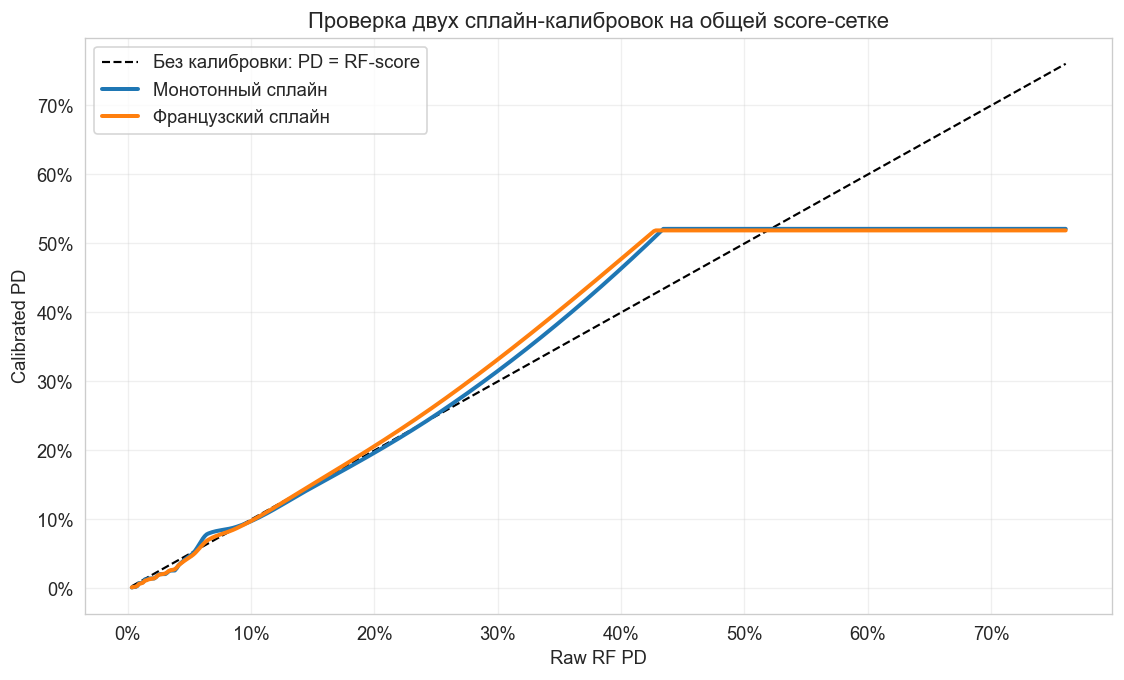

In [10]:
mono = calibrators["Монотонный сплайн"]
french = calibrators["Французский сплайн"]

mono_pd = mono.predict(score_grid)
french_pd = french.predict(score_grid)
diff = np.abs(mono_pd - french_pd)

print("Сравнение монотонного и французского сплайна:")
print(f"Средняя абсолютная разница: {diff.mean():.6f}")
print(f"Максимальная абсолютная разница: {diff.max():.6f}")

fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.plot(score_grid, score_grid, "--", color="black", lw=1.3, label="Без калибровки: PD = RF-score")
ax.plot(score_grid, mono_pd, label="Монотонный сплайн", linewidth=2.4)
ax.plot(score_grid, french_pd, label="Французский сплайн", linewidth=2.4)
ax.set_xlabel("Raw RF PD")
ax.set_ylabel("Calibrated PD")
ax.set_title("Проверка двух сплайн-калибровок на общей score-сетке")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Сплайн-калибровки строятся по одной и той же in-time информации, но отличаются математикой: обычный монотонный сплайн сглаживает эмпирическую default rate как функцию raw score, а французский вариант сначала стабилизирует уровень через logit-калибровку и затем сглаживает остаточную поправку. Поэтому их кривые могут быть близкими, но это не дублирование одного и того же объекта.


### Проверка формы калибровочных функций

Этот график показывает **математическую функцию**, которую выучил каждый калибратор: `raw RF PD -> calibrated PD`. Здесь монотонность обязательна по смыслу PD: если исходный RF-score выше, откалиброванная PD не должна становиться ниже. Изотоническая регрессия поэтому выглядит ступенчатой, а сплайны могут иметь плато на краях диапазона, где данных мало и экстраполяция фиксируется по последнему надежному уровню. Это не OOT-качество, а форма преобразования.


In [11]:
print("Метрики, reliability-графики и bootstrap-проверка рассчитаны в следующем разделе. Финальный выбор метода делается после статистики и RWA-блока.")


Метрики, reliability-графики и bootstrap-проверка рассчитаны в следующем разделе. Финальный выбор метода делается после статистики и RWA-блока.


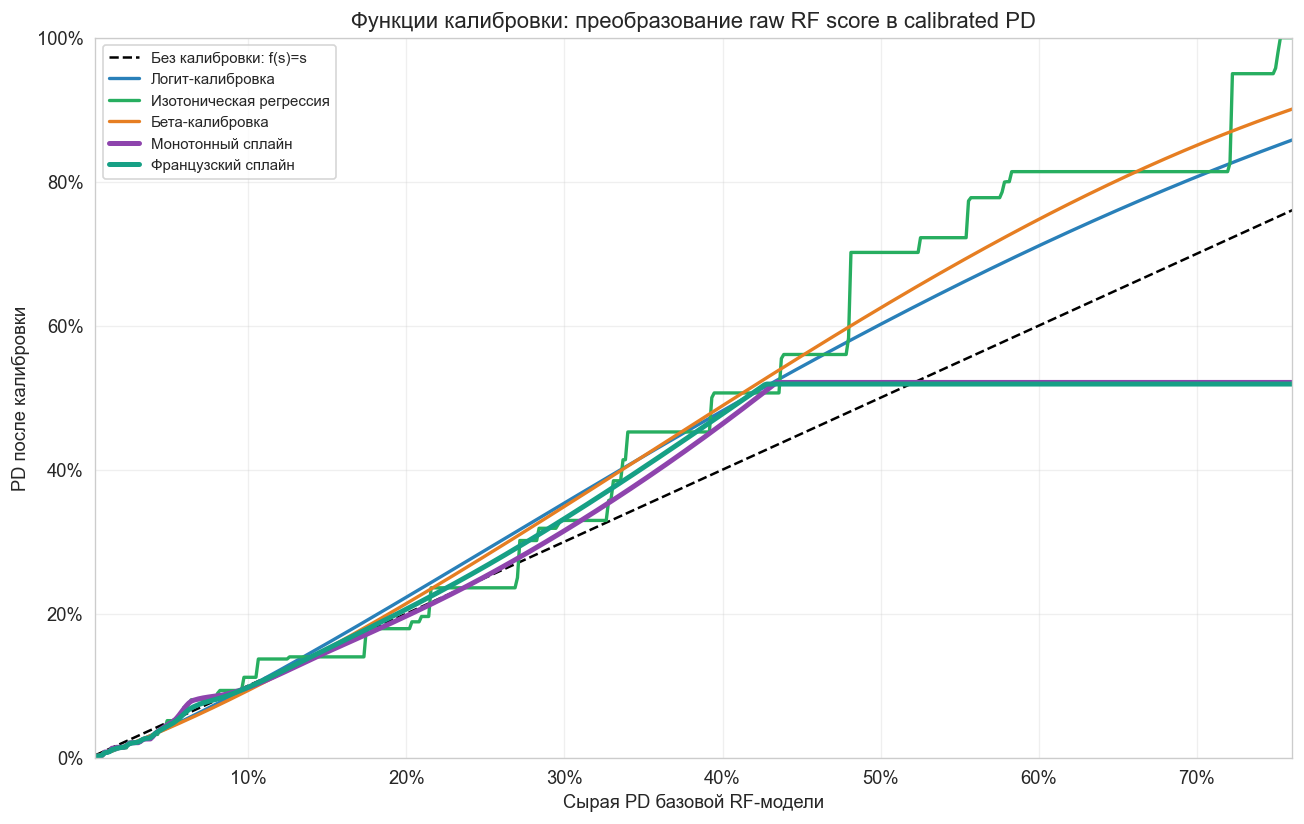

Диапазон графика ограничен 0.1% и 99.9% перцентилями calibration-скоров, чтобы редкие экстремумы не сжимали основную область.


In [12]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(score_grid, score_grid, "k--", lw=1.5, label="Без калибровки: f(s)=s")

for (name, cal), color in zip(calibrators.items(), COLORS[1:]):
    calibrated_grid = cal.predict(score_grid)
    lw = 3.0 if "сплайн" in name.lower() else 2.0
    ax.plot(score_grid, calibrated_grid, color=color, lw=lw, label=name)

ax.set_xlabel("Сырая PD базовой RF-модели")
ax.set_ylabel("PD после калибровки")
ax.set_title("Функции калибровки: преобразование raw RF score в calibrated PD")
ax.set_xlim(score_grid.min(), score_grid.max())
ax.set_ylim(0, min(1.0, max(max(cal.predict(score_grid)) for cal in calibrators.values()) * 1.10))
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Диапазон графика ограничен 0.1% и 99.9% перцентилями calibration-скоров, чтобы редкие экстремумы не сжимали основную область.")


In [13]:
parameter_rows = []
for name, cal in calibrators.items():
    row = {"Метод": name}

    if hasattr(cal, "_model") and hasattr(cal._model, "coef_"):
        row["Параметры"] = (
            f"a={float(cal._model.coef_[0][0]):.4f}, "
            f"b={float(cal._model.intercept_[0]):.4f}"
        )
    elif hasattr(cal, "a_"):
        row["Параметры"] = (
            f"a={cal.a_:.4f}, b={cal.b_:.4f}, c={cal.c_:.4f}, "
            f"success={cal.success_}"
        )
    elif hasattr(cal, "bin_stats_") and cal.bin_stats_ is not None:
        row["Параметры"] = f"число бинов={len(cal.bin_stats_)}"
    else:
        row["Параметры"] = "непараметрический метод"

    parameter_rows.append(row)

display(pd.DataFrame(parameter_rows).set_index("Метод"))


,Параметры
Метод,
Логит-калибровка,"a=1.1993, b=0.4135"
Изотоническая регрессия,непараметрический метод
Бета-калибровка,"a=1.1192, b=-1.6697, c=0.1280, success=True"
Монотонный сплайн,число бинов=30
Французский сплайн,число бинов=30


## 6. OOT-результаты, reliability и устойчивость

Здесь все методы сравниваются на одном и том же OOT-портфеле 2024 года. Важно не смешивать два разных графика: функция калибровки из раздела 5 показывает выученное преобразование `score -> PD`, а reliability-график ниже показывает **фактическую проверку** на OOT: средняя прогнозная PD в группе против реальной доли дефолтов в этой группе. Поэтому reliability-точки не обязаны идеально возрастать: это эмпирические частоты дефолта, и в low-PD группах даже несколько дефолтов заметно двигают точку.


**Как читать reliability-графики.**  
Точки строятся по квантильным бинам: в каждом бине примерно одинаковое число активов. Это делает группы сопоставимыми по размеру, но не убирает случайный шум фактических дефолтов. Поэтому ниже точки показаны с 95% Wilson-интервалами, а не соединены в толстую ломаную линию: соединенная линия выглядит как функция, хотя на самом деле это набор OOT-наблюдений по группам.


In [14]:
results = [summary_metrics(y_test.values, scores_test, name="RF без калибровки")]
for name, probs in calibrated_probs.items():
    results.append(summary_metrics(y_test.values, probs, name=name))

df_results = pd.DataFrame(results).set_index("method")

print("Метрики на OOT-выборке, 2024 год:")
print("  Brier Score, Log-Loss, ECE  — чем меньше, тем лучше")
print("  HL p-value                  — чем больше, тем лучше, но при большом n тест часто слишком строгий")
print("  Slope ~ 1, Intercept ~ 0    — ближе к идеальной калибровке")

df_results_ru = df_results.rename(columns={
    "brier_score": "Brier Score",
    "log_loss": "Log-Loss",
    "ece_uniform": "ECE (фикс. бины)",
    "ece_quantile": "ECE (квант. бины)",
    "hl_chi2": "HL chi2",
    "hl_p_value": "HL p-value",
    "cal_slope": "Cal. slope",
    "cal_intercept": "Cal. intercept",
})

display(
    df_results_ru.round({
        "Brier Score": 5,
        "Log-Loss": 5,
        "ECE (фикс. бины)": 5,
        "ECE (квант. бины)": 5,
        "HL chi2": 3,
        "HL p-value": 4,
        "Cal. slope": 4,
        "Cal. intercept": 4,
    })
)

disc_rows = []
all_preds = {"RF без калибровки": scores_test, **calibrated_probs}
all_methods = all_preds
for name, probs in all_preds.items():
    disc_rows.append(discrimination_metrics(y_test.values, probs, name=name))

df_disc = pd.DataFrame(disc_rows).set_index("method")
print("\nМетрики ранжирования (AUC / Gini / KS):")
display(df_disc)
print("Комментарий: строго монотонные преобразования обычно сохраняют ранжирование;")
print("изотоническая и сплайн-калибровка могут немного менять AUC/Gini из-за ties или сглаживания.")

prob_range_rows = []
for name, probs in all_preds.items():
    prob_range_rows.append({
        "method": name,
        "min_pd": np.min(probs),
        "p95_pd": np.quantile(probs, 0.95),
        "max_pd": np.max(probs),
        "mean_pd": np.mean(probs),
    })

df_prob_ranges = pd.DataFrame(prob_range_rows).set_index("method")
df_prob_ranges_ru = df_prob_ranges.rename(columns={
    "min_pd": "Мин. PD",
    "p95_pd": "95-й перцентиль PD",
    "max_pd": "Макс. PD",
    "mean_pd": "Средняя PD",
})
print("\nФактический диапазон PD на OOT:")
display(df_prob_ranges_ru.style.format("{:.2%}"))


Метрики на OOT-выборке, 2024 год:
  Brier Score, Log-Loss, ECE  — чем меньше, тем лучше
  HL p-value                  — чем больше, тем лучше, но при большом n тест часто слишком строгий
  Slope ~ 1, Intercept ~ 0    — ближе к идеальной калибровке


,Brier Score,Log-Loss,ece,ECE (фикс. бины),ECE (квант. бины),HL chi2,HL p-value,Cal. slope,Cal. intercept
method,,,,,,,,,
RF без калибровки,0.03430,0.13138,0.00699,0.00784,0.00699,22.982,0.0034,1.1552,0.2747
Логит-калибровка,0.03408,0.13060,0.00572,0.00554,0.00572,24.188,0.0021,0.9630,-0.1243
Изотоническая регрессия,0.03402,0.13332,0.00468,0.00297,0.00468,70.244,0.0000,0.9129,-0.2289
Бета-калибровка,0.03400,0.13037,0.00580,0.00529,0.00580,21.154,0.0068,0.9657,-0.1191
Монотонный сплайн,0.03459,0.13207,0.00591,0.00577,0.00591,34.364,0.0000,1.0386,0.0949
Французский сплайн,0.03464,0.13196,0.00457,0.00527,0.00457,28.652,0.0004,1.0174,0.0427



Метрики ранжирования (AUC / Gini / KS):


,auc_roc,gini,ks_stat
method,,,
RF без калибровки,0.8786,0.7572,0.6219
Логит-калибровка,0.8786,0.7572,0.6219
Изотоническая регрессия,0.8789,0.7578,0.6196
Бета-калибровка,0.8786,0.7572,0.6219
Монотонный сплайн,0.8783,0.7566,0.6219
Французский сплайн,0.8785,0.7569,0.6219


Комментарий: строго монотонные преобразования обычно сохраняют ранжирование;
изотоническая и сплайн-калибровка могут немного менять AUC/Gini из-за ties или сглаживания.

Фактический диапазон PD на OOT:


,Мин. PD,95-й перцентиль PD,Макс. PD,Средняя PD
method,,,,
RF без калибровки,0.31%,25.70%,86.79%,4.90%
Логит-калибровка,0.15%,29.74%,93.53%,4.91%
Изотоническая регрессия,0.00%,23.59%,100.00%,4.91%
Бета-калибровка,0.18%,28.97%,96.61%,4.90%
Монотонный сплайн,0.14%,26.02%,52.12%,4.67%
Французский сплайн,0.15%,27.47%,51.89%,4.70%


### Bootstrap-проверка устойчивости

Bootstrap ниже показывает, насколько устойчивы различия между методами на OOT. Если доверительные интервалы сильно перекрываются, статистически методы близки, даже если точечная метрика немного отличается.


In [15]:
from sklearn.metrics import roc_auc_score

boot_rows = []

print("Bootstrap 95% CI (1000 итераций) на OOT Test...")
print(f"{'Метод':<28} {'Brier':>7}  {'95% CI Brier':>18}  {'AUC':>7}  {'95% CI AUC':>18}")
print("-" * 85)

for name, probs in all_preds.items():
    ci_brier = bootstrap_ci(y_test.values, probs, brier_score,   n_iter=1000, random_state=42)
    ci_auc   = bootstrap_ci(y_test.values, probs, roc_auc_score, n_iter=1000, random_state=42)

    boot_rows.append({
        "method": name,
        "brier_point": ci_brier["point_estimate"],
        "brier_ci_lower": ci_brier["ci_lower"],
        "brier_ci_upper": ci_brier["ci_upper"],
        "auc_point": ci_auc["point_estimate"],
        "auc_ci_lower": ci_auc["ci_lower"],
        "auc_ci_upper": ci_auc["ci_upper"],
    })

    print(
        f"{name:<28} "
        f"{ci_brier['point_estimate']:>7.5f}  "
        f"[{ci_brier['ci_lower']:.5f}, {ci_brier['ci_upper']:.5f}]  "
        f"{ci_auc['point_estimate']:>7.4f}  "
        f"[{ci_auc['ci_lower']:.4f}, {ci_auc['ci_upper']:.4f}]"
    )

df_boot = pd.DataFrame(boot_rows).set_index("method")

print("\nИнтерпретация: если интервалы по Brier заметно перекрываются, различия между методами невелики.")


Bootstrap 95% CI (1000 итераций) на OOT Test...
Метод                          Brier        95% CI Brier      AUC          95% CI AUC
-------------------------------------------------------------------------------------


RF без калибровки            0.03430  [0.03118, 0.03735]   0.8786  [0.8597, 0.8971]


Логит-калибровка             0.03408  [0.03099, 0.03707]   0.8786  [0.8597, 0.8971]


Изотоническая регрессия      0.03402  [0.03083, 0.03707]   0.8789  [0.8605, 0.8965]


Бета-калибровка              0.03400  [0.03090, 0.03699]   0.8786  [0.8597, 0.8971]


Монотонный сплайн            0.03459  [0.03148, 0.03761]   0.8783  [0.8596, 0.8966]


Французский сплайн           0.03464  [0.03156, 0.03765]   0.8785  [0.8595, 0.8969]

Интерпретация: если интервалы по Brier заметно перекрываются, различия между методами невелики.


### Reliability-графики и распределение по бинам

Для визуальной проверки калибровки используются квантильные бины. Это не распределение портфеля, а проверочные группы примерно одинакового размера. Монотонной должна быть калибровочная функция из раздела 5; фактическая default rate по OOT-бинам может колебаться вокруг идеальной диагонали из-за конечного числа дефолтов. Если Wilson-интервалы перекрывают диагональ, визуальное отклонение не стоит переинтерпретировать.


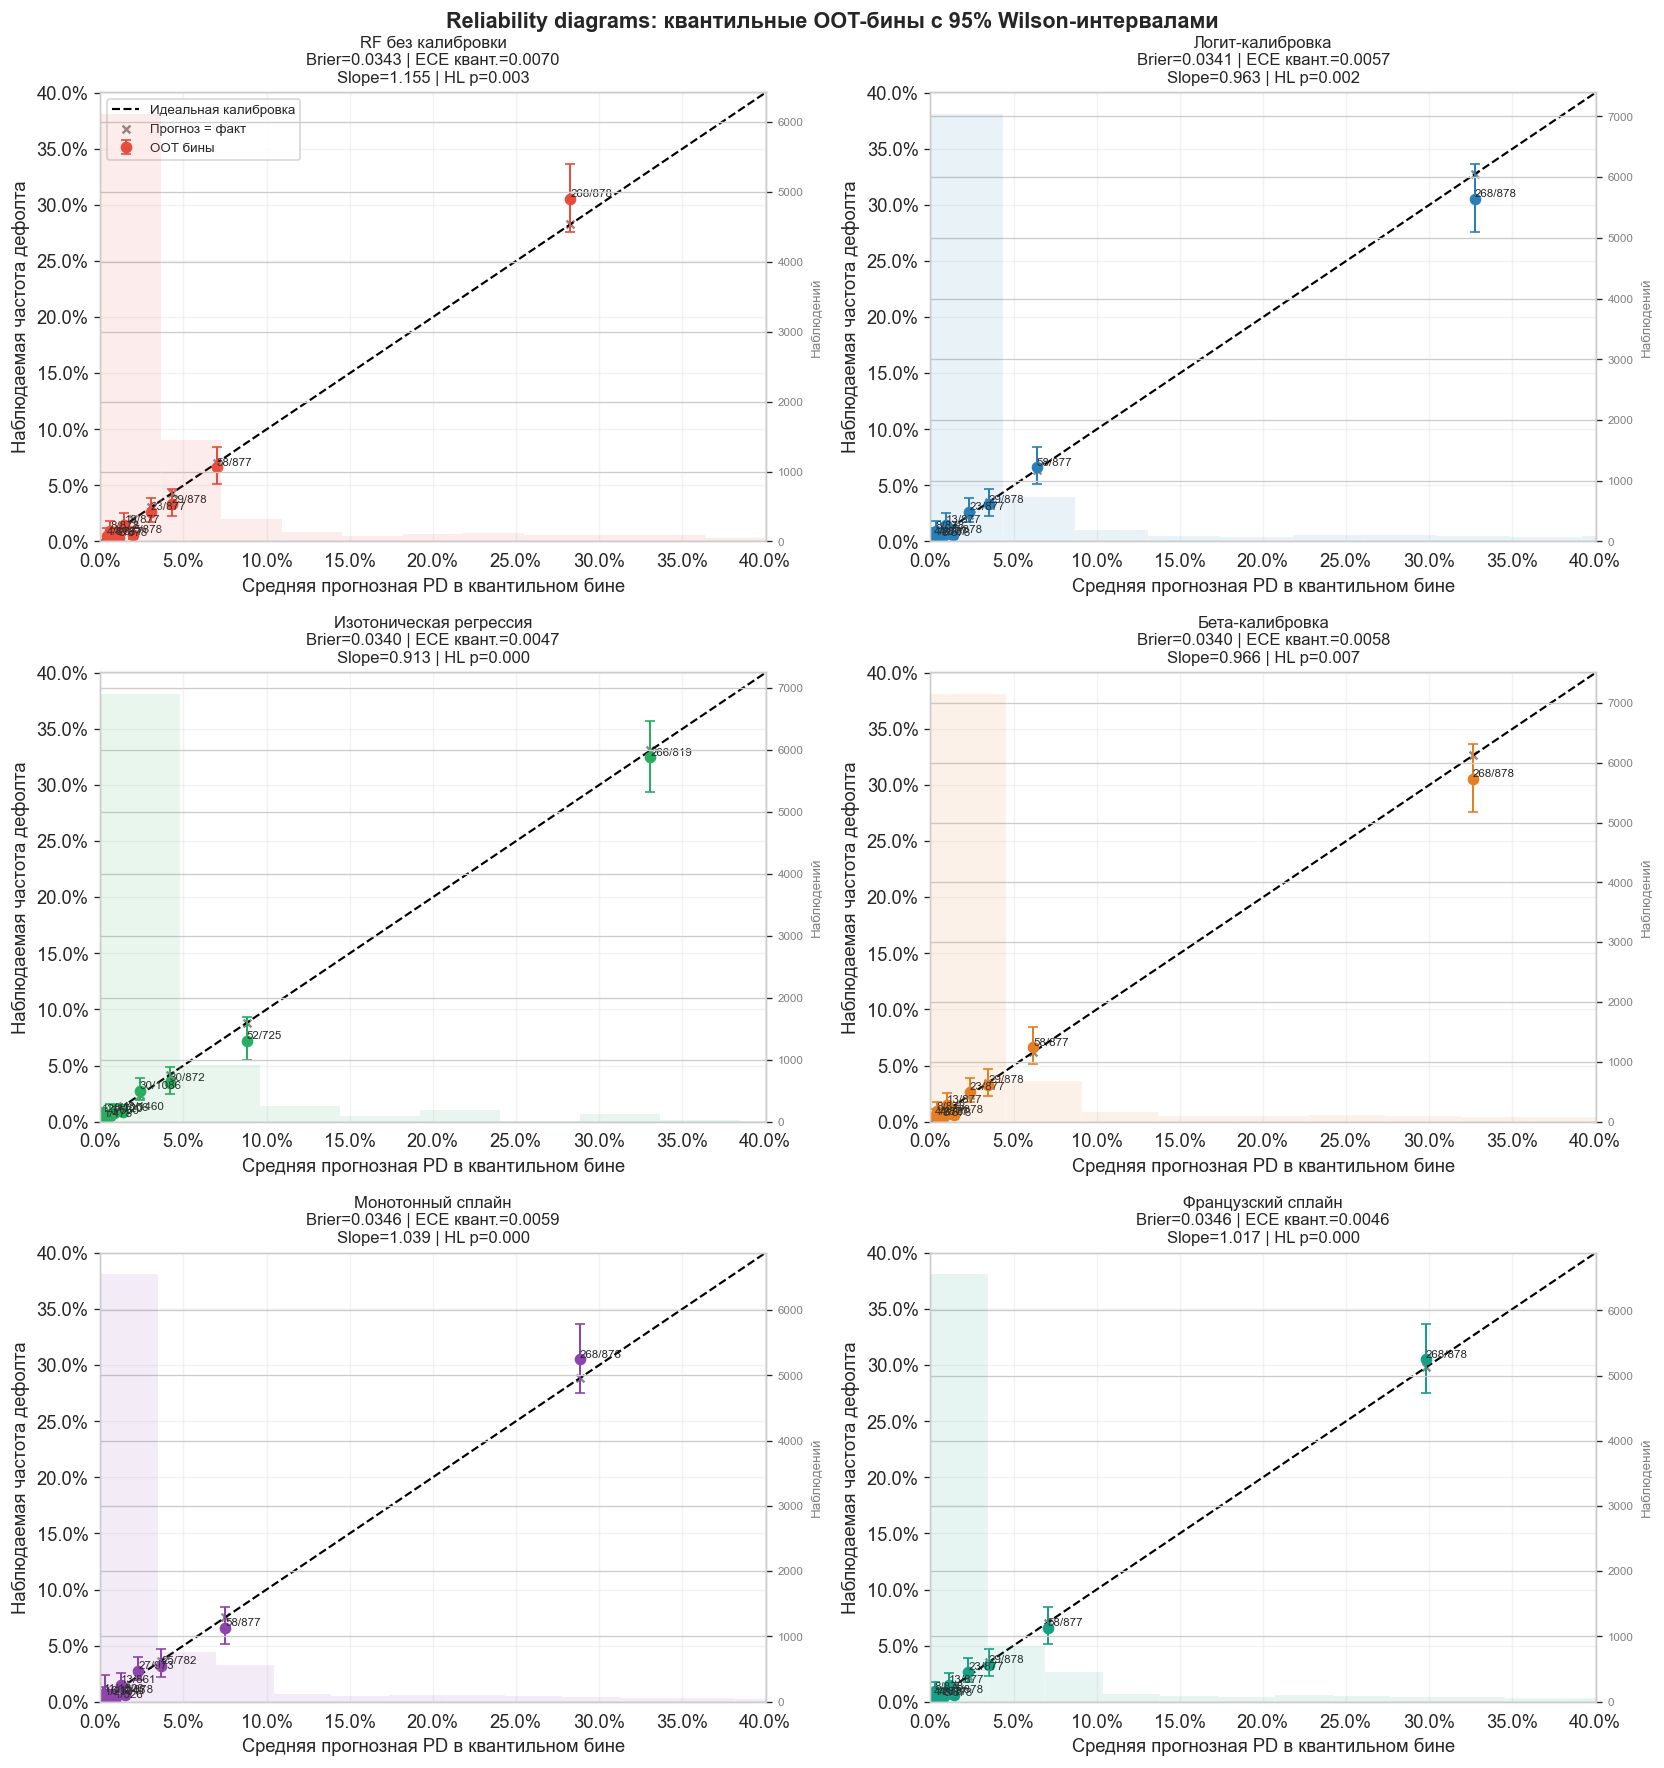

Reliability tables by method:

RF без калибровки


,n_assets,mean_pred,observed_default_rate,defaults,abs_calibration_gap,ci_lower,ci_upper,ci_half_width
0,878,0.41%,0.46%,4.000000,0.04%,0.18%,1.17%,0.71%
1,878,0.60%,0.91%,8.000000,0.31%,0.46%,1.79%,0.88%
2,877,0.85%,0.46%,4.000000,0.39%,0.18%,1.17%,0.71%
3,878,1.11%,0.34%,3.000000,0.77%,0.12%,1.00%,0.66%
4,877,1.45%,1.48%,13.000000,0.03%,0.87%,2.52%,1.04%
5,878,1.97%,0.57%,5.000000,1.40%,0.24%,1.33%,0.76%
6,877,3.05%,2.62%,23.000000,0.42%,1.75%,3.90%,1.28%
7,878,4.28%,3.30%,29.000000,0.98%,2.31%,4.70%,1.40%
8,877,7.01%,6.61%,58.000000,0.40%,5.15%,8.45%,1.84%
9,878,28.28%,30.52%,268.000000,2.24%,27.57%,33.65%,3.13%



Логит-калибровка


,n_assets,mean_pred,observed_default_rate,defaults,abs_calibration_gap,ci_lower,ci_upper,ci_half_width
0,878,0.21%,0.46%,4.000000,0.25%,0.18%,1.17%,0.71%
1,878,0.33%,0.91%,8.000000,0.58%,0.46%,1.79%,0.88%
2,877,0.50%,0.46%,4.000000,0.04%,0.18%,1.17%,0.71%
3,878,0.69%,0.34%,3.000000,0.35%,0.12%,1.00%,0.66%
4,877,0.95%,1.48%,13.000000,0.53%,0.87%,2.52%,1.04%
5,878,1.38%,0.57%,5.000000,0.81%,0.24%,1.33%,0.76%
6,877,2.33%,2.62%,23.000000,0.29%,1.75%,3.90%,1.28%
7,878,3.52%,3.30%,29.000000,0.22%,2.31%,4.70%,1.40%
8,877,6.41%,6.61%,58.000000,0.20%,5.15%,8.45%,1.84%
9,878,32.77%,30.52%,268.000000,2.25%,27.57%,33.65%,3.13%



Изотоническая регрессия


...

,n_assets,mean_pred,observed_default_rate,defaults,abs_calibration_gap,ci_lower,ci_upper,ci_half_width
0,878,0.25%,0.46%,4.000000,0.21%,0.18%,1.17%,0.71%
1,878,0.37%,0.91%,8.000000,0.54%,0.46%,1.79%,0.88%
2,877,0.55%,0.46%,4.000000,0.09%,0.18%,1.17%,0.71%
3,878,0.75%,0.34%,3.000000,0.41%,0.12%,1.00%,0.66%
4,877,1.01%,1.48%,13.000000,0.47%,0.87%,2.52%,1.04%
5,878,1.43%,0.57%,5.000000,0.86%,0.24%,1.33%,0.76%
6,877,2.35%,2.62%,23.000000,0.27%,1.75%,3.90%,1.28%
7,878,3.48%,3.30%,29.000000,0.17%,2.31%,4.70%,1.40%
8,877,6.19%,6.61%,58.000000,0.43%,5.15%,8.45%,1.84%
9,878,32.65%,30.52%,268.000000,2.13%,27.57%,33.65%,3.13%



Монотонный сплайн


,n_assets,mean_pred,observed_default_rate,defaults,abs_calibration_gap,ci_lower,ci_upper,ci_half_width
0,1526,0.18%,0.72%,11.000000,0.54%,0.40%,1.29%,0.57%
1,230,0.27%,0.43%,1.000000,0.16%,0.08%,2.42%,1.99%
2,1245,0.61%,0.48%,6.000000,0.13%,0.22%,1.05%,0.57%
3,526,0.87%,0.19%,1.000000,0.68%,0.03%,1.07%,0.88%
4,861,1.26%,1.51%,13.000000,0.25%,0.88%,2.57%,1.06%
5,878,1.48%,0.57%,5.000000,0.91%,0.24%,1.33%,0.76%
6,973,2.29%,2.77%,27.000000,0.48%,1.91%,4.01%,1.23%
7,782,3.66%,3.20%,25.000000,0.47%,2.17%,4.68%,1.48%
8,877,7.53%,6.61%,58.000000,0.92%,5.15%,8.45%,1.84%
9,878,28.85%,30.52%,268.000000,1.67%,27.57%,33.65%,3.13%



Французский сплайн


,n_assets,mean_pred,observed_default_rate,defaults,abs_calibration_gap,ci_lower,ci_upper,ci_half_width
0,878,0.18%,0.46%,4.000000,0.28%,0.18%,1.17%,0.71%
1,878,0.26%,0.91%,8.000000,0.65%,0.46%,1.79%,0.88%
2,877,0.52%,0.46%,4.000000,0.06%,0.18%,1.17%,0.71%
3,878,0.77%,0.34%,3.000000,0.43%,0.12%,1.00%,0.66%
4,877,1.12%,1.48%,13.000000,0.36%,0.87%,2.52%,1.04%
5,878,1.44%,0.57%,5.000000,0.87%,0.24%,1.33%,0.76%
6,877,2.29%,2.62%,23.000000,0.34%,1.75%,3.90%,1.28%
7,878,3.53%,3.30%,29.000000,0.23%,2.31%,4.70%,1.40%
8,877,7.06%,6.61%,58.000000,0.44%,5.15%,8.45%,1.84%
9,878,29.83%,30.52%,268.000000,0.69%,27.57%,33.65%,3.13%


In [16]:
def quantile_reliability_table(y_true, y_prob, n_bins=10, z=1.96):
    tmp = pd.DataFrame({"y": np.asarray(y_true, dtype=float), "pd": np.asarray(y_prob, dtype=float)})
    tmp["bin"] = pd.qcut(tmp["pd"], q=n_bins, duplicates="drop")
    out = (
        tmp.groupby("bin", observed=True)
        .agg(
            n_assets=("pd", "size"),
            mean_pred=("pd", "mean"),
            observed_default_rate=("y", "mean"),
            defaults=("y", "sum"),
        )
        .reset_index(drop=True)
    )
    out["abs_calibration_gap"] = (out["observed_default_rate"] - out["mean_pred"]).abs()

    n = out["n_assets"].astype(float)
    p = out["observed_default_rate"].astype(float)
    denom = 1.0 + z**2 / n
    center = (p + z**2 / (2.0 * n)) / denom
    half_width = z * np.sqrt((p * (1.0 - p) / n) + (z**2 / (4.0 * n**2))) / denom
    out["ci_lower"] = np.clip(center - half_width, 0.0, 1.0)
    out["ci_upper"] = np.clip(center + half_width, 0.0, 1.0)
    out["ci_half_width"] = out["ci_upper"] - out["observed_default_rate"]
    return out


reliability_tables = {
    name: quantile_reliability_table(y_test.values, probs, n_bins=10)
    for name, probs in all_methods.items()
}

n_methods = len(all_methods)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

max_axis = 0.0
for table in reliability_tables.values():
    max_axis = max(
        max_axis,
        float(table["mean_pred"].max()),
        float(table["ci_upper"].max()),
    )
max_axis = min(1.0, max(0.10, max_axis * 1.12))

for i, (name, probs) in enumerate(all_methods.items()):
    ax = axes[i]
    table = reliability_tables[name]
    m = summary_metrics(y_test.values, probs)
    color = COLORS[i % len(COLORS)]

    ax.plot([0, max_axis], [0, max_axis], "k--", lw=1.3, label="Идеальная калибровка")
    yerr = np.vstack([
        table["observed_default_rate"] - table["ci_lower"],
        table["ci_upper"] - table["observed_default_rate"],
    ])
    ax.errorbar(
        table["mean_pred"],
        table["observed_default_rate"],
        yerr=yerr,
        fmt="o",
        color=color,
        ecolor=color,
        elinewidth=1.2,
        capsize=3,
        ms=6,
        label="OOT бины",
    )
    ax.scatter(
        table["mean_pred"],
        table["mean_pred"],
        marker="x",
        color="black",
        s=22,
        alpha=0.45,
        label="Прогноз = факт",
    )
    for _, row in table.iterrows():
        ax.text(
            row["mean_pred"],
            row["observed_default_rate"],
            f'{int(row["defaults"]):.0f}/{int(row["n_assets"]):.0f}',
            fontsize=7,
            ha="left",
            va="bottom",
        )

    ax2 = ax.twinx()
    hist_max = min(1.0, max(float(np.quantile(probs, 0.995)), 0.10))
    ax2.hist(probs, bins=np.linspace(0, hist_max, 16), alpha=0.10, color=color)
    ax2.set_ylabel("Наблюдений", fontsize=8, color="gray")
    ax2.tick_params(axis="y", labelsize=7, labelcolor="gray")

    subtitle = (
        f'Brier={m["brier_score"]:.4f} | ECE квант.={m["ece_quantile"]:.4f}\n'
        f'Slope={m["cal_slope"]:.3f} | HL p={m["hl_p_value"]:.3f}'
    )
    ax.set_title(f"{name}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Средняя прогнозная PD в квантильном бине")
    ax.set_ylabel("Наблюдаемая частота дефолта")
    ax.set_xlim(0, max_axis)
    ax.set_ylim(0, max_axis)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    if i == 0:
        ax.legend(loc="upper left", fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Reliability diagrams: квантильные OOT-бины с 95% Wilson-интервалами", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Reliability tables by method:")
for name, table in reliability_tables.items():
    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)
    display(
        table.style.format({
            "mean_pred": "{:.2%}",
            "observed_default_rate": "{:.2%}",
            "abs_calibration_gap": "{:.2%}",
            "ci_lower": "{:.2%}",
            "ci_upper": "{:.2%}",
            "ci_half_width": "{:.2%}",
        })
    )


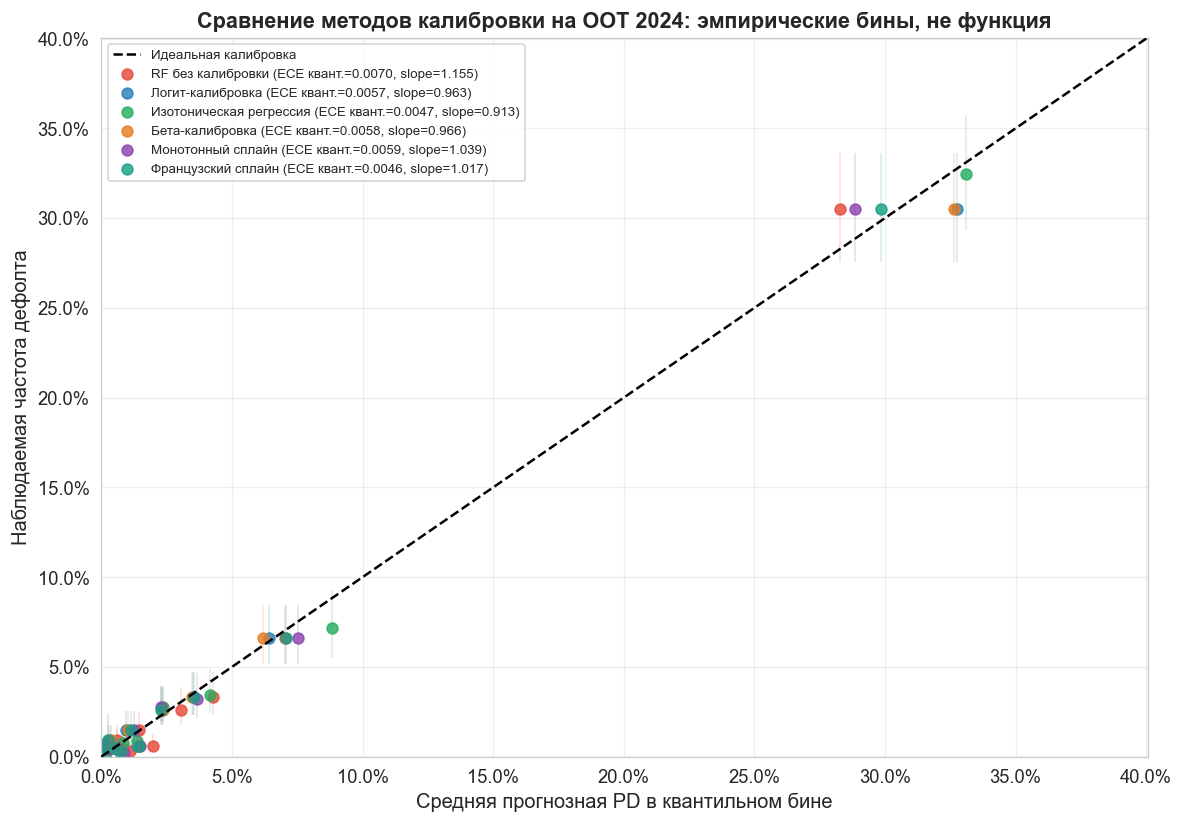

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))

max_axis = 0.0
for table in reliability_tables.values():
    max_axis = max(max_axis, float(table["mean_pred"].max()), float(table["ci_upper"].max()))
max_axis = min(1.0, max(0.10, max_axis * 1.12))

ax.plot([0, max_axis], [0, max_axis], "k--", lw=1.5, label="Идеальная калибровка", zorder=5)

for i, (name, table) in enumerate(reliability_tables.items()):
    m = summary_metrics(y_test.values, all_methods[name])
    color = COLORS[i % len(COLORS)]
    label = f"{name} (ECE квант.={m['ece_quantile']:.4f}, slope={m['cal_slope']:.3f})"
    ax.scatter(
        table["mean_pred"],
        table["observed_default_rate"],
        color=color,
        s=42,
        alpha=0.82,
        label=label,
    )
    ax.vlines(
        table["mean_pred"],
        table["ci_lower"],
        table["ci_upper"],
        color=color,
        alpha=0.18,
        linewidth=1.0,
    )

ax.set_xlim(0, max_axis)
ax.set_ylim(0, max_axis)
ax.set_xlabel("Средняя прогнозная PD в квантильном бине", fontsize=12)
ax.set_ylabel("Наблюдаемая частота дефолта", fontsize=12)
ax.set_title("Сравнение методов калибровки на OOT 2024: эмпирические бины, не функция", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Backtesting expected defaults по OOT-портфелю

После проверки формы калибровочных функций и reliability-графиков полезно сделать самый простой портфельный backtesting: сколько дефолтов реально случилось на OOT и сколько дефолтов ожидала каждая PD-шкала. Здесь сравниваются RF без калибровки и все методы калибровки на одном и том же OOT-наборе заемщиков.


Простой backtesting expected defaults на OOT 2024:
Фактическое число дефолтов: 415
Ближе всего к факту по expected defaults: Французский сплайн (ошибка 2.53).


,n_obs,defaults,expected_defaults,default_gap,abs_default_gap,calibration_ratio,actual_default_rate,predicted_default_rate,avg_pd,relative_default_gap_pct
method,,,,,,,,,,
Французский сплайн,8776,415,412.47,2.53,2.53,1.01,4.73%,4.70%,4.70%,0.61%
Монотонный сплайн,8776,415,409.72,5.28,5.28,1.01,4.73%,4.67%,4.67%,1.27%
RF без калибровки,8776,415,430.25,-15.25,15.25,0.96,4.73%,4.90%,4.90%,-3.68%
Бета-калибровка,8776,415,430.37,-15.37,15.37,0.96,4.73%,4.90%,4.90%,-3.70%
Логит-калибровка,8776,415,430.96,-15.96,15.96,0.96,4.73%,4.91%,4.91%,-3.85%
Изотоническая регрессия,8776,415,431.23,-16.23,16.23,0.96,4.73%,4.91%,4.91%,-3.91%


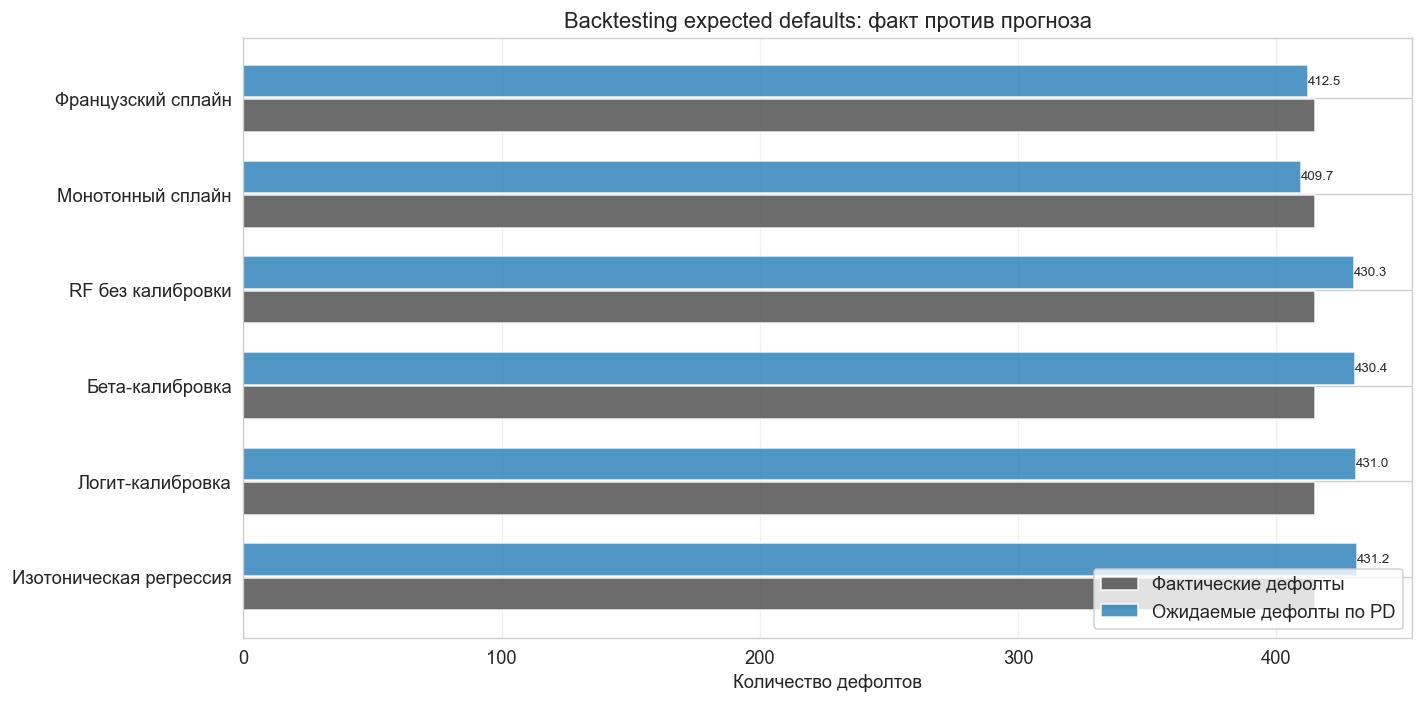

Интерпретация: calibration_ratio около 1 означает, что метод попал в общий уровень дефолтности портфеля. Это не заменяет reliability-графики: метод может хорошо попасть в общее число дефолтов, но хуже распределять риск по группам заемщиков.


In [18]:
method_summary = method_portfolio_summary(
    raw_score_frame,
    all_preds,
    default_col="default",
)

backtest_table = method_summary[[
    "n_obs",
    "avg_pd",
    "defaults",
    "expected_defaults",
    "default_gap",
    "calibration_ratio",
]].copy()
backtest_table["actual_default_rate"] = backtest_table["defaults"] / backtest_table["n_obs"]
backtest_table["predicted_default_rate"] = (
    backtest_table["expected_defaults"] / backtest_table["n_obs"]
)
backtest_table["abs_default_gap"] = backtest_table["default_gap"].abs()
backtest_table["relative_default_gap_pct"] = np.where(
    backtest_table["defaults"] > 0,
    backtest_table["default_gap"] / backtest_table["defaults"],
    np.nan,
)
backtest_table = backtest_table[[
    "n_obs",
    "defaults",
    "expected_defaults",
    "default_gap",
    "abs_default_gap",
    "calibration_ratio",
    "actual_default_rate",
    "predicted_default_rate",
    "avg_pd",
    "relative_default_gap_pct",
]]

best_backtest = backtest_table["abs_default_gap"].idxmin()
actual_defaults = float(backtest_table["defaults"].iloc[0])

print("Простой backtesting expected defaults на OOT 2024:")
print(f"Фактическое число дефолтов: {actual_defaults:.0f}")
print(
    f"Ближе всего к факту по expected defaults: {best_backtest} "
    f"(ошибка {backtest_table.loc[best_backtest, 'default_gap']:.2f})."
)

display(
    backtest_table
    .sort_values("abs_default_gap")
    .style.format({
        "avg_pd": "{:.2%}",
        "defaults": "{:.0f}",
        "expected_defaults": "{:.2f}",
        "default_gap": "{:.2f}",
        "abs_default_gap": "{:.2f}",
        "calibration_ratio": "{:.2f}",
        "actual_default_rate": "{:.2%}",
        "predicted_default_rate": "{:.2%}",
        "relative_default_gap_pct": "{:.2%}",
    })
)

plot_backtest = (
    backtest_table
    .reset_index(names="method")
    .sort_values("abs_default_gap", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(plot_backtest))
ax.barh(
    y_pos - 0.18,
    plot_backtest["defaults"],
    height=0.34,
    color="#4c4c4c",
    alpha=0.82,
    label="Фактические дефолты",
)
ax.barh(
    y_pos + 0.18,
    plot_backtest["expected_defaults"],
    height=0.34,
    color="#2980b9",
    alpha=0.82,
    label="Ожидаемые дефолты по PD",
)
for i, row in plot_backtest.iterrows():
    ax.text(
        row["expected_defaults"],
        y_pos[list(plot_backtest.index).index(i)] + 0.18,
        f'{row["expected_defaults"]:.1f}',
        va="center",
        ha="left",
        fontsize=8,
    )
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_backtest["method"])
ax.set_xlabel("Количество дефолтов")
ax.set_title("Backtesting expected defaults: факт против прогноза")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.28)
plt.tight_layout()
plt.show()

print(
    "Интерпретация: calibration_ratio около 1 означает, что метод попал в общий уровень "
    "дефолтности портфеля. Это не заменяет reliability-графики: метод может хорошо попасть "
    "в общее число дефолтов, но хуже распределять риск по группам заемщиков."
)


## 8. Влияние калибровки на резервы, RWA и требуемый капитал

После статистической диагностики и backtesting expected defaults каждая версия PD переводится в прикладные показатели: expected loss, unexpected-loss capital, RWA и требуемый капитал при нормативе 8%. Этот блок не выбирает модель по минимальному капиталу автоматически; он показывает экономический эффект разных PD-шкал.


### Rating Master Scale: калибровка PD по рейтинговой шкале

В этом блоке портфель собирается не напрямую по индивидуальным PD, а по рейтинговой шкале `A1 ... E`. Каждый рейтинг получает свою PD. Затем PD по рейтингам сдвигаются на logit-шкале так, чтобы средневзвешенная PD портфеля совпала с целевой CT. Для первого приближения CT берется из общего train+calibration in-time периода, а EAD каждого актива равен `1_000_000`.

In [19]:
TARGET_CT = float(y_calib.mean())
ASSET_EAD = 1_000_000.0

df_calib_master = df.loc[y_calib.index].copy()
df_test_master = df.loc[y_test.index].copy()
df_calib_master["master_rating"] = assign_master_scale_ratings(
    scores_calib, reference_scores=scores_calib
)
df_test_master["master_rating"] = assign_master_scale_ratings(
    scores_test, reference_scores=scores_calib
)

rating_scale_predictions = {
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

master_scale_panel = compare_methods_by_rating_master_scale(
    df_test_master,
    rating_scale_predictions,
    score_values=scores_test,
    target_pd=TARGET_CT,
    default_asset_ead=ASSET_EAD,
)
master_scale_summary = summarize_rating_scale(master_scale_panel, method_col="method")


master_scale_capital = rating_scale_capital(
    master_scale_panel,
    assumptions=IRBAssumptions(lgd=0.40, maturity_years=2.5, ead=ASSET_EAD),
    method_col="method",
)

rating_pd_matrix = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="pd_rating")
    .loc[list(MASTER_SCALE_RATINGS)]
)

display(
    rating_pd_matrix.style.format("{:.2%}")
)

# Critical methodology check: every method must use the same borrowers
# in every rating bucket. Calibration methods may change only PD, not
# the portfolio composition.
master_scale_structure_check = validate_common_rating_structure(master_scale_panel)

print(f"Target CT по train+calibration-периоду: {TARGET_CT:.2%}")
print(f"OOT default rate:                 {y_test.mean():.2%}")
print(f"EAD на один актив:                {ASSET_EAD:,.0f}")

display(
    master_scale_summary[[
        "n_assets",
        "target_weighted_pd",
        "defaults",
        "expected_defaults",
        "pd_min",
        "pd_max",
    ]]
    .style.format({
        "target_weighted_pd": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "pd_min": "{:.2%}",
        "pd_max": "{:.2%}",
    })
)

master_scale_method = "RF \u0431\u0435\u0437 \u043a\u0430\u043b\u0438\u0431\u0440\u043e\u0432\u043a\u0438"
master_scale_view_cols = [
    "rating",
    "avg_score",
    "n_assets",
    "portfolio_count_share",
    "observed_default_rate",
    "pd_before_target",
    "pd_rating",
    "one_minus_pd",
    "expected_defaults",
]
display(
    master_scale_panel.loc[
        master_scale_panel["method"] == master_scale_method,
        master_scale_view_cols,
    ]
    .style.format({
        "avg_score": "{:.4f}",
        "portfolio_count_share": "{:.1%}",
        "observed_default_rate": "{:.2%}",
        "pd_before_target": "{:.2%}",
        "pd_rating": "{:.2%}",
        "one_minus_pd": "{:.2%}",
        "expected_defaults": "{:.2f}",
    })
)


method,RF без калибровки,Бета-калибровка,Изотоническая регрессия,Логит-калибровка,Монотонный сплайн,Французский сплайн
rating,,,,,,
A1,0.38%,0.23%,0.04%,0.19%,0.15%,0.17%
A2,0.50%,0.30%,0.12%,0.26%,0.22%,0.24%
A3,0.66%,0.42%,0.14%,0.37%,0.29%,0.32%
B1,0.86%,0.56%,0.45%,0.50%,0.62%,0.57%
B2,1.04%,0.70%,0.71%,0.64%,0.84%,0.76%
B3,1.28%,0.87%,0.94%,0.82%,1.10%,0.99%
C1,1.57%,1.11%,1.32%,1.05%,1.43%,1.29%
C2,2.06%,1.51%,1.41%,1.46%,1.62%,1.57%
C3,2.95%,2.27%,2.21%,2.25%,2.31%,2.33%


Target CT по train+calibration-периоду: 4.81%
OOT default rate:                 4.73%
EAD на один актив:                1,000,000


,n_assets,target_weighted_pd,defaults,expected_defaults,pd_min,pd_max
method,,,,,,
RF без калибровки,8776,4.81%,415.000000,421.88,0.38%,31.30%
Бета-калибровка,8776,4.81%,415.000000,421.88,0.23%,36.66%
Изотоническая регрессия,8776,4.81%,415.000000,421.88,0.04%,35.40%
Логит-калибровка,8776,4.81%,415.000000,421.88,0.19%,36.61%
Монотонный сплайн,8776,4.81%,415.000000,421.88,0.15%,33.44%
Французский сплайн,8776,4.81%,415.000000,421.88,0.17%,34.40%


,rating,avg_score,n_assets,portfolio_count_share,observed_default_rate,pd_before_target,pd_rating,one_minus_pd,expected_defaults
0,A1,0.0039,643,7.3%,0.31%,0.39%,0.38%,99.62%,2.47
1,A2,0.0051,623,7.1%,0.96%,0.51%,0.50%,99.50%,3.11
2,A3,0.0068,713,8.1%,0.56%,0.68%,0.66%,99.34%,4.72
3,B1,0.0088,650,7.4%,0.46%,0.88%,0.86%,99.14%,5.57
4,B2,0.0107,630,7.2%,0.63%,1.07%,1.04%,98.96%,6.58
5,B3,0.0131,683,7.8%,1.32%,1.31%,1.28%,98.72%,8.71
6,C1,0.0161,686,7.8%,0.58%,1.61%,1.57%,98.43%,10.79
7,C2,0.0211,729,8.3%,1.10%,2.11%,2.06%,97.94%,15.03
8,C3,0.0302,659,7.5%,2.73%,3.02%,2.95%,97.05%,19.46
9,D1,0.0391,646,7.4%,3.10%,3.91%,3.82%,96.18%,24.69


### Fixed PD master scale and RWA by rating

This compact block applies the external PD boundaries A1...E directly to each method's calibrated PD. The table always keeps the full rating axis from A1 to E, including zero-EAD rows for empty buckets. This block does not change the calibration split or reliability plots.

In [20]:
fixed_scale_bounds = master_scale_bounds_table()
display(
    fixed_scale_bounds.set_index("rating").style.format({
        "pd_lower": "{:.2%}",
        "pd_upper": "{:.2%}",
        "pd_avg_master": "{:.2%}",
    })
)

fixed_master_scale_panel = method_master_scale_distribution(
    df_test_master,
    rating_scale_predictions,
    default_asset_ead=ASSET_EAD,
)

fixed_master_scale_rwa_by_rating = rating_scale_capital_by_rating(
    fixed_master_scale_panel,
    assumptions=IRBAssumptions(lgd=0.40, maturity_years=2.5, ead=ASSET_EAD),
    method_col="method",
    rating_col="rating",
    pd_col="pd_rating",
)

fixed_master_scale_rwa_summary = (
    fixed_master_scale_rwa_by_rating
    .groupby("method", sort=False)
    .agg(
        total_ead=("total_ead", "sum"),
        total_expected_loss=("total_expected_loss", "sum"),
        total_unexpected_loss_capital=("total_unexpected_loss_capital", "sum"),
        total_el_plus_ul_capital=("total_el_plus_ul_capital", "sum"),
        total_rwa=("total_rwa", "sum"),
        total_required_capital=("total_required_capital", "sum"),
    )
)
fixed_master_scale_rwa_summary["rwa_rate_to_ead"] = (
    fixed_master_scale_rwa_summary["total_rwa"] / fixed_master_scale_rwa_summary["total_ead"]
)

fixed_master_scale_counts = (
    fixed_master_scale_panel
    .pivot(index="rating", columns="method", values="n_assets")
    .reindex(MASTER_SCALE_RATINGS)
)
synthetic_oot_rating_counts = (
    df_test_master.groupby("rating", observed=False)
    .agg(n_assets=("default", "size"), defaults=("default", "sum"), bad_rate=("default", "mean"))
    .reindex(["A", "B", "C", "D", "E"])
)
synthetic_oot_rating_counts["asset_share"] = synthetic_oot_rating_counts["n_assets"] / len(df_test_master)

print("Original synthetic OOT portfolio: asset counts by source rating")
display(
    synthetic_oot_rating_counts.style.format({
        "asset_share": "{:.1%}",
        "bad_rate": "{:.2%}",
    })
)

print("Fixed PD master scale: asset counts by rating")
display(fixed_master_scale_counts.style.format("{:,.0f}"))

print("Fixed PD master scale: RWA summary")
display(
    fixed_master_scale_rwa_summary.style.format({
        "total_ead": "{:,.0f}",
        "total_expected_loss": "{:,.0f}",
        "total_unexpected_loss_capital": "{:,.0f}",
        "total_el_plus_ul_capital": "{:,.0f}",
        "total_rwa": "{:,.0f}",
        "total_required_capital": "{:,.0f}",
        "rwa_rate_to_ead": "{:.2%}",
    })
)

first_rating_check = (
    fixed_master_scale_rwa_by_rating
    .groupby("method", sort=False)["rating"]
    .first()
)
if not (first_rating_check == "A1").all():
    raise ValueError("Fixed master scale RWA table must start with A1 for every method.")

zero_axis_check = (
    fixed_master_scale_rwa_by_rating
    .groupby("method", sort=False)
    .size()
)
if not (zero_axis_check == len(MASTER_SCALE_RATINGS)).all():
    raise ValueError("Fixed master scale RWA table must keep all A1...E rows for every method.")


,pd_lower,pd_upper,pd_avg_master
rating,,,
A1,0.00%,0.06%,0.05%
A2,0.06%,0.08%,0.07%
A3,0.08%,0.10%,0.09%
B1,0.10%,0.14%,0.12%
B2,0.14%,0.30%,0.22%
B3,0.30%,0.65%,0.47%
C1,0.65%,1.05%,0.85%
C2,1.05%,1.82%,1.55%
C3,1.82%,2.91%,2.37%


Original synthetic OOT portfolio: asset counts by source rating


,n_assets,defaults,bad_rate,asset_share
rating,,,,
A,257,0,0.00%,2.9%
B,3134,13,0.41%,35.7%
C,3619,65,1.80%,41.2%
D,1421,156,10.98%,16.2%
E,345,181,52.46%,3.9%


Fixed PD master scale: asset counts by rating


method,RF без калибровки,Бета-калибровка,Изотоническая регрессия,Логит-калибровка,Монотонный сплайн,Французский сплайн
rating,,,,,,
A1,0,0,222,0,0,0
A2,0,0,424,0,0,0
A3,0,0,0,0,0,0
B1,0,0,"1,074",0,460,0
B2,0,884,478,"1,171","1,227","1,626"
B3,"1,534","1,781",560,"1,739",621,750
C1,"1,347","1,403","1,056","1,312","1,337","1,348"
C2,"1,769","1,233","1,460","1,120","1,590","1,547"
C3,962,848,"1,086",798,"1,154","1,073"


Fixed PD master scale: RWA summary


,total_ead,total_expected_loss,total_unexpected_loss_capital,total_el_plus_ul_capital,total_rwa,total_required_capital,rwa_rate_to_ead
method,,,,,,,
RF без калибровки,"8,776,000,000","180,890,320","771,962,018","952,852,338","9,649,525,219","771,962,018",109.95%
Бета-калибровка,"8,776,000,000","171,038,720","705,361,560","876,400,280","8,817,019,504","705,361,560",100.47%
Изотоническая регрессия,"8,776,000,000","159,983,520","667,954,855","827,938,375","8,349,435,685","667,954,855",95.14%
Логит-калибровка,"8,776,000,000","173,003,640","696,663,607","869,667,247","8,708,295,091","696,663,607",99.23%
Монотонный сплайн,"8,776,000,000","170,715,240","706,423,104","877,138,344","8,830,288,798","706,423,104",100.62%
Французский сплайн,"8,776,000,000","172,207,860","707,393,172","879,601,032","8,842,414,651","707,393,172",100.76%


### Asset distribution by predicted fixed master-scale bucket

The six charts below show how each calibrated PD method distributes the same OOT portfolio across predicted PD buckets on the fixed A1...E master scale. These are model-assigned buckets, not the original synthetic `rating` mix. Empty buckets are kept on the axis, so each chart is directly comparable.

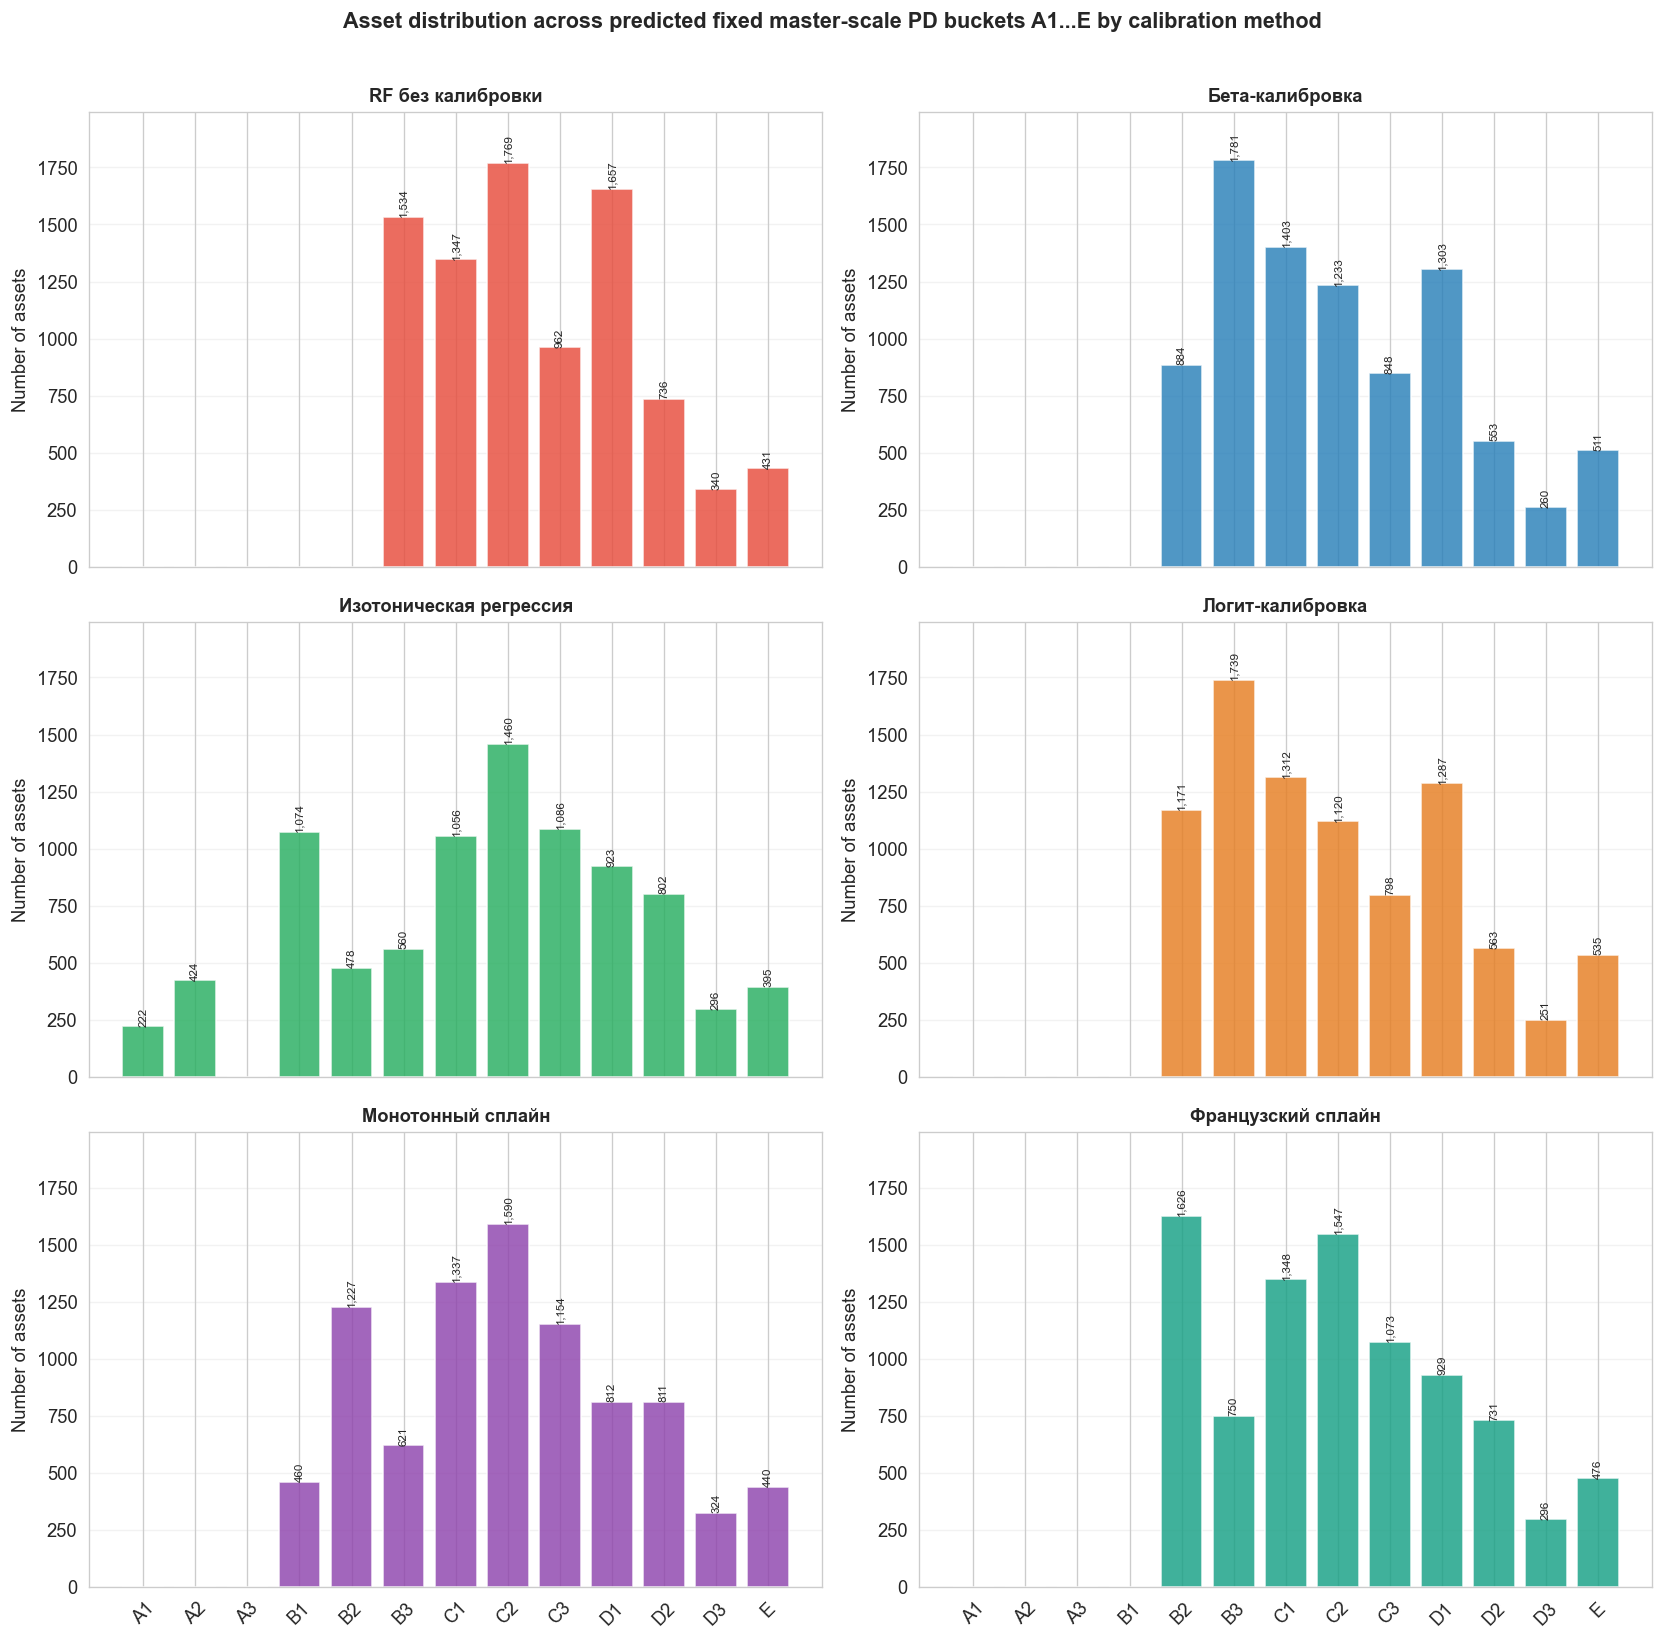

In [21]:
plot_methods = list(fixed_master_scale_counts.columns)
ncols = 2
nrows = int(np.ceil(len(plot_methods) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), sharex=True)
axes = np.atleast_1d(axes).flatten()

max_assets = int(fixed_master_scale_counts.max().max())
for i, method in enumerate(plot_methods):
    ax = axes[i]
    values = fixed_master_scale_counts[method].reindex(MASTER_SCALE_RATINGS).fillna(0).astype(int)
    bars = ax.bar(MASTER_SCALE_RATINGS, values, color=COLORS[i % len(COLORS)], alpha=0.82)
    ax.set_title(method, fontsize=11, fontweight="bold")
    ax.set_ylabel("Number of assets")
    ax.set_ylim(0, max_assets * 1.12 if max_assets > 0 else 1)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=45)

    for bar, value in zip(bars, values):
        if value > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{value:,.0f}",
                ha="center",
                va="bottom",
                fontsize=7,
                rotation=90,
            )

for j in range(len(plot_methods), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Asset distribution across predicted fixed master-scale PD buckets A1...E by calibration method",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()


1. A1...E is the fixed PD master scale used for final rating assignment.
2. Rating assignment now uses each method's calibrated PD, so portfolio counts may differ by method.
3. RWA/EL calculations use only the master-scale average PD (`pd_avg_master` / `pd_rating`).
4. Lower and upper PD bounds are used only to assign ratings.


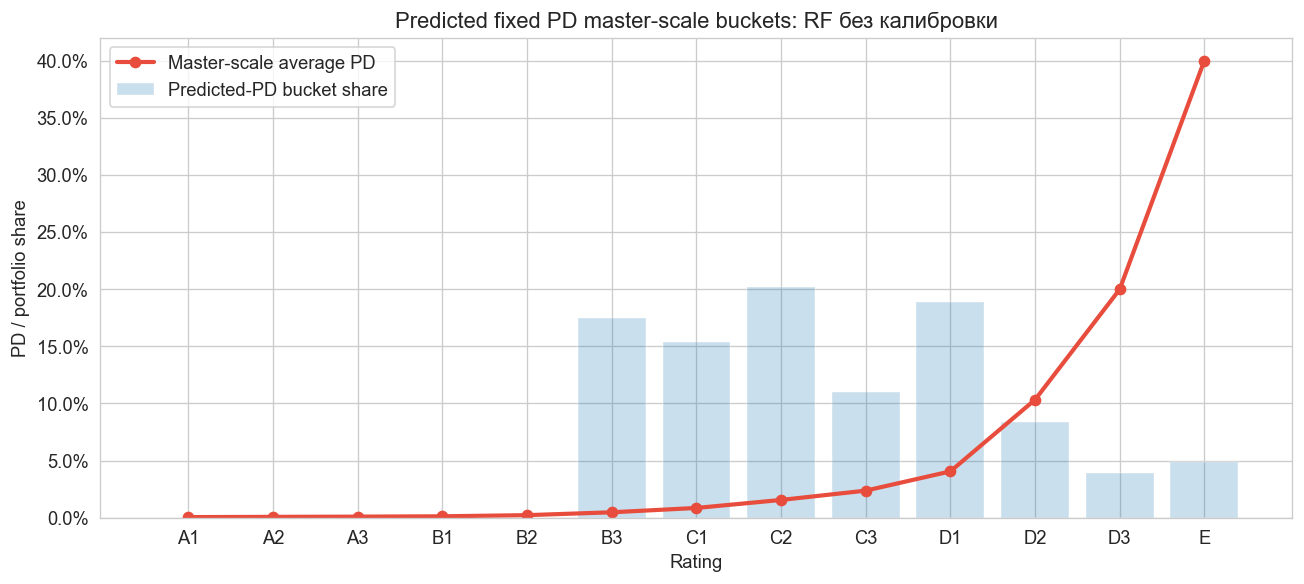

,total_ead,total_expected_loss,total_unexpected_loss_capital,total_el_plus_ul_capital,total_rwa,total_required_capital,rwa_rate_to_ead
method,,,,,,,
RF без калибровки,"8,776,000,000","180,890,320","771,962,018","952,852,338","9,649,525,219","771,962,018",109.95%
Бета-калибровка,"8,776,000,000","171,038,720","705,361,560","876,400,280","8,817,019,504","705,361,560",100.47%
Изотоническая регрессия,"8,776,000,000","159,983,520","667,954,855","827,938,375","8,349,435,685","667,954,855",95.14%
Логит-калибровка,"8,776,000,000","173,003,640","696,663,607","869,667,247","8,708,295,091","696,663,607",99.23%
Монотонный сплайн,"8,776,000,000","170,715,240","706,423,104","877,138,344","8,830,288,798","706,423,104",100.62%
Французский сплайн,"8,776,000,000","172,207,860","707,393,172","879,601,032","8,842,414,651","707,393,172",100.76%


In [22]:
base_fixed_method = "RF \u0431\u0435\u0437 \u043a\u0430\u043b\u0438\u0431\u0440\u043e\u0432\u043a\u0438"
plot_scale = fixed_master_scale_panel[
    fixed_master_scale_panel["method"] == base_fixed_method
].copy()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    plot_scale["rating"],
    plot_scale["pd_rating"],
    marker="o",
    linewidth=2.5,
    color=COLORS[0],
    label="Master-scale average PD",
)
ax.bar(
    plot_scale["rating"],
    plot_scale["portfolio_count_share"],
    alpha=0.25,
    color=COLORS[1],
    label="Predicted-PD bucket share",
)
ax.set_xlabel("Rating")
ax.set_ylabel("PD / portfolio share")
ax.set_title(f"Predicted fixed PD master-scale buckets: {base_fixed_method}")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

display(
    fixed_master_scale_rwa_summary[[
        "total_ead",
        "total_expected_loss",
        "total_unexpected_loss_capital",
        "total_el_plus_ul_capital",
        "total_rwa",
        "total_required_capital",
        "rwa_rate_to_ead",
    ]]
    .style.format({
        "total_ead": "{:,.0f}",
        "total_expected_loss": "{:,.0f}",
        "total_unexpected_loss_capital": "{:,.0f}",
        "total_el_plus_ul_capital": "{:,.0f}",
        "total_rwa": "{:,.0f}",
        "total_required_capital": "{:,.0f}",
        "rwa_rate_to_ead": "{:.2%}",
    })
)


### Fixed master-scale consistency checks

Each calibration method now assigns assets to the fixed A1...E PD boundaries independently. The rating mix is allowed to differ by method, but every method must keep the full A1...E axis, start at A1, and preserve the same total OOT portfolio size/EAD.

In [23]:
fixed_axis_check = (
    fixed_master_scale_panel
    .groupby("method", sort=False)
    .agg(
        first_rating=("rating", "first"),
        n_rating_rows=("rating", "size"),
        total_assets=("n_assets", "sum"),
        total_ead=("total_ead", "sum"),
    )
)
fixed_axis_check["starts_with_a1"] = fixed_axis_check["first_rating"].eq("A1")
fixed_axis_check["has_full_axis"] = fixed_axis_check["n_rating_rows"].eq(len(MASTER_SCALE_RATINGS))
fixed_axis_check["same_total_assets"] = fixed_axis_check["total_assets"].eq(len(df_test_master))
fixed_axis_check["same_total_ead"] = fixed_axis_check["total_ead"].eq(len(df_test_master) * ASSET_EAD)

if not fixed_axis_check[["starts_with_a1", "has_full_axis", "same_total_assets", "same_total_ead"]].all().all():
    raise ValueError("Fixed master-scale tables are not synchronized across methods.")

display(
    fixed_axis_check.style.format({
        "total_ead": "{:,.0f}",
    })
)
print("Check passed: every method keeps A1...E, starts at A1, and covers the same OOT portfolio.")
print("Rating counts may differ by method because each calibrated PD series is bucketed independently.")


,first_rating,n_rating_rows,total_assets,total_ead,starts_with_a1,has_full_axis,same_total_assets,same_total_ead
method,,,,,,,,
RF без калибровки,A1,13,8776,"8,776,000,000",True,True,True,True
Логит-калибровка,A1,13,8776,"8,776,000,000",True,True,True,True
Изотоническая регрессия,A1,13,8776,"8,776,000,000",True,True,True,True
Бета-калибровка,A1,13,8776,"8,776,000,000",True,True,True,True
Монотонный сплайн,A1,13,8776,"8,776,000,000",True,True,True,True
Французский сплайн,A1,13,8776,"8,776,000,000",True,True,True,True


Check passed: every method keeps A1...E, starts at A1, and covers the same OOT portfolio.
Rating counts may differ by method because each calibrated PD series is bucketed independently.


### Rating PD comparison across methods

The tables and charts below use the fixed master-scale panel only. `avg_pd` is the empirical mean calibrated PD inside each rating bucket, while `pd_avg_master` is the ideal fixed master-scale PD used for EL/RWA calculations. The combined charts show all methods on the same A1...E axis.

Mean calibrated PD inside each fixed rating bucket


method,RF без калибровки,Бета-калибровка,Изотоническая регрессия,Логит-калибровка,Монотонный сплайн,Французский сплайн
rating,,,,,,
A1,,,0.00%,,,
A2,,,0.07%,,,
A3,,,,,,
B1,,,0.12%,,0.14%,
B2,,0.25%,0.19%,0.23%,0.21%,0.21%
B3,0.48%,0.46%,0.60%,0.47%,0.40%,0.43%
C1,0.85%,0.83%,0.82%,0.83%,0.82%,0.78%
C2,1.39%,1.36%,1.36%,1.36%,1.39%,1.33%
C3,2.27%,2.38%,2.36%,2.38%,2.33%,2.38%


Number of OOT assets inside each fixed rating bucket


method,RF без калибровки,Бета-калибровка,Изотоническая регрессия,Логит-калибровка,Монотонный сплайн,Французский сплайн
rating,,,,,,
A1,0,0,222,0,0,0
A2,0,0,424,0,0,0
A3,0,0,0,0,0,0
B1,0,0,"1,074",0,460,0
B2,0,884,478,"1,171","1,227","1,626"
B3,"1,534","1,781",560,"1,739",621,750
C1,"1,347","1,403","1,056","1,312","1,337","1,348"
C2,"1,769","1,233","1,460","1,120","1,590","1,547"
C3,962,848,"1,086",798,"1,154","1,073"


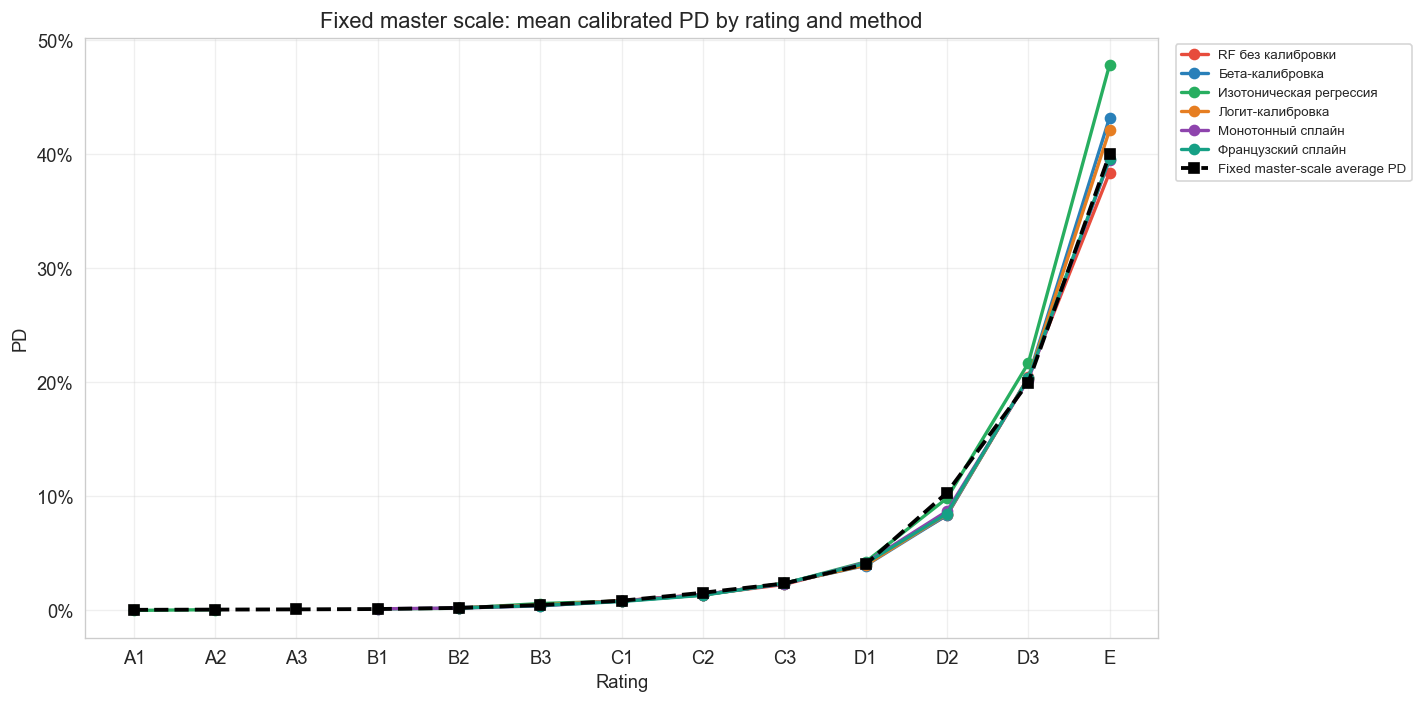

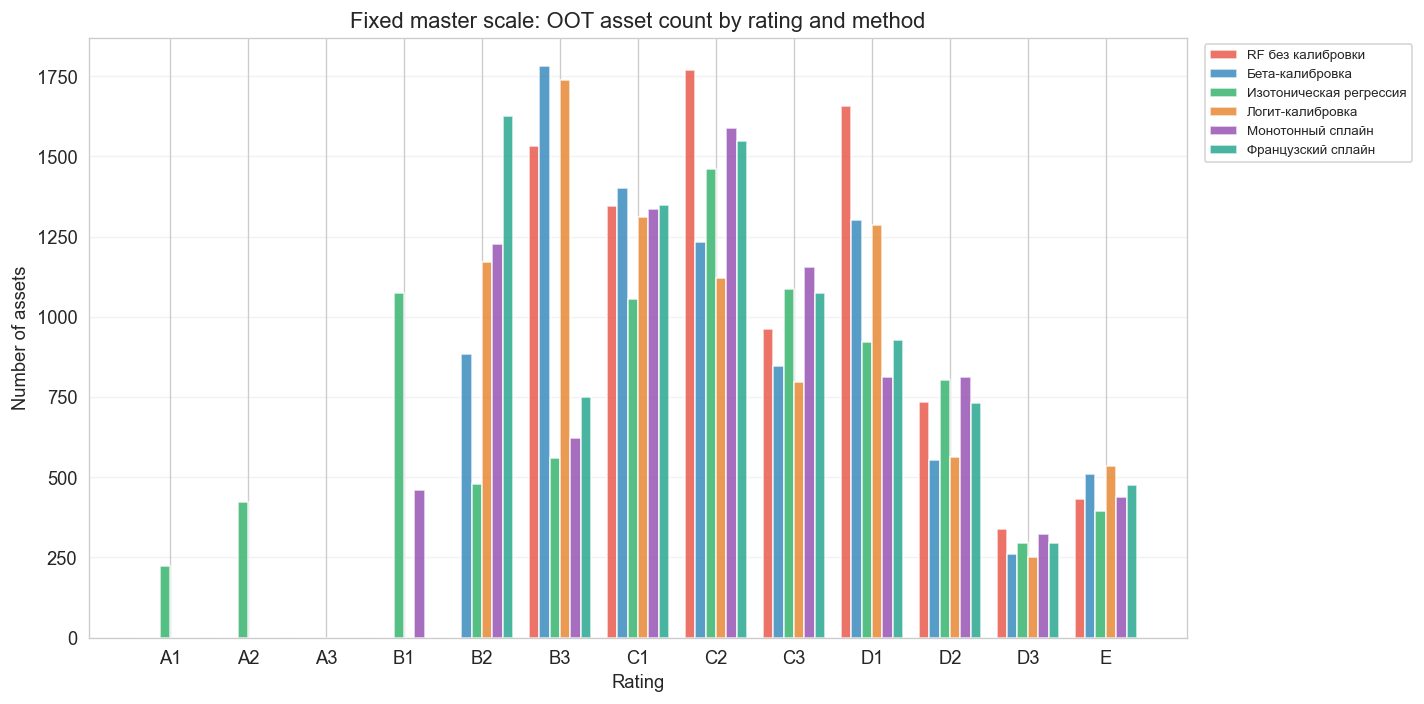

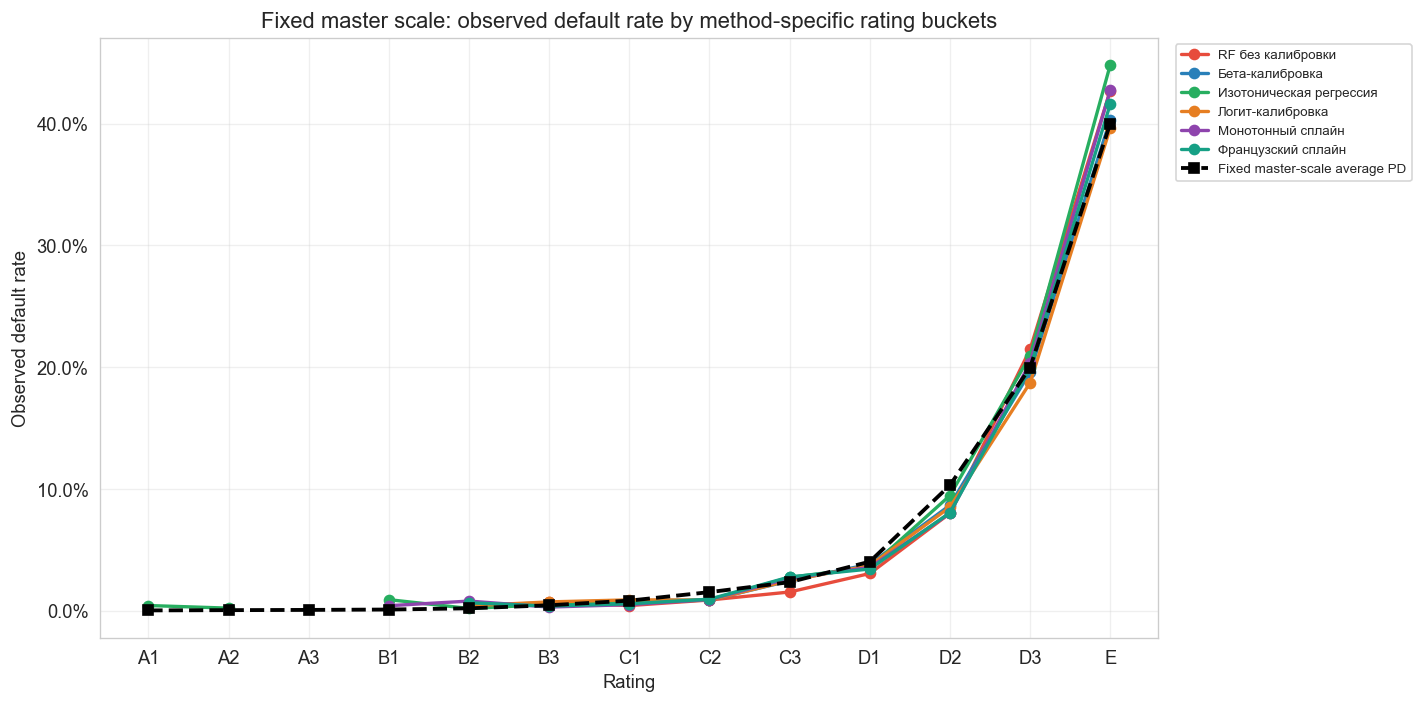

Fixed master-scale RWA / EL / capital summary


,total_ead,total_expected_loss,total_unexpected_loss_capital,total_el_plus_ul_capital,total_rwa,total_required_capital,rwa_rate_to_ead
method,,,,,,,
RF без калибровки,"8,776,000,000","180,890,320","771,962,018","952,852,338","9,649,525,219","771,962,018",109.95%
Бета-калибровка,"8,776,000,000","171,038,720","705,361,560","876,400,280","8,817,019,504","705,361,560",100.47%
Изотоническая регрессия,"8,776,000,000","159,983,520","667,954,855","827,938,375","8,349,435,685","667,954,855",95.14%
Логит-калибровка,"8,776,000,000","173,003,640","696,663,607","869,667,247","8,708,295,091","696,663,607",99.23%
Монотонный сплайн,"8,776,000,000","170,715,240","706,423,104","877,138,344","8,830,288,798","706,423,104",100.62%
Французский сплайн,"8,776,000,000","172,207,860","707,393,172","879,601,032","8,842,414,651","707,393,172",100.76%


In [24]:
# =========================
# Fixed master scale: method comparison
# =========================

fixed_rating_avg_pd_matrix = (
    fixed_master_scale_panel
    .assign(avg_pd_plot=lambda x: x["avg_pd"].where(x["n_assets"] > 0))
    .pivot(index="rating", columns="method", values="avg_pd_plot")
    .reindex(MASTER_SCALE_RATINGS)
)

fixed_rating_count_matrix = (
    fixed_master_scale_panel
    .pivot(index="rating", columns="method", values="n_assets")
    .reindex(MASTER_SCALE_RATINGS)
)

fixed_rating_observed_dr_matrix = (
    fixed_master_scale_panel
    .assign(observed_dr_plot=lambda x: x["observed_default_rate"].where(x["n_assets"] > 0))
    .pivot(index="rating", columns="method", values="observed_dr_plot")
    .reindex(MASTER_SCALE_RATINGS)
)

ideal_pd_by_rating = fixed_scale_bounds.set_index("rating")["pd_avg_master"].reindex(MASTER_SCALE_RATINGS)

print("Mean calibrated PD inside each fixed rating bucket")
display(
    fixed_rating_avg_pd_matrix
    .style
    .format("{:.2%}", na_rep="")
    .background_gradient(axis=None, cmap="YlOrRd")
)

print("Number of OOT assets inside each fixed rating bucket")
display(
    fixed_rating_count_matrix
    .style
    .format("{:,.0f}")
    .background_gradient(axis=None, cmap="Blues")
)

# Chart 1: all methods, mean calibrated PD by rating, plus the ideal master-scale PD.
fig, ax = plt.subplots(figsize=(12, 6))
for i, method in enumerate(fixed_rating_avg_pd_matrix.columns):
    ax.plot(
        fixed_rating_avg_pd_matrix.index,
        fixed_rating_avg_pd_matrix[method],
        marker="o",
        linewidth=2,
        color=COLORS[i % len(COLORS)],
        label=method,
    )
ax.plot(
    ideal_pd_by_rating.index,
    ideal_pd_by_rating,
    color="black",
    linestyle="--",
    marker="s",
    linewidth=2.3,
    label="Fixed master-scale average PD",
)
ax.set_title("Fixed master scale: mean calibrated PD by rating and method")
ax.set_xlabel("Rating")
ax.set_ylabel("PD")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

# Chart 2: all methods, asset counts by rating.
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(MASTER_SCALE_RATINGS))
methods = list(fixed_rating_count_matrix.columns)
bar_width = min(0.8 / max(len(methods), 1), 0.14)
for i, method in enumerate(methods):
    offset = (i - (len(methods) - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        fixed_rating_count_matrix[method].fillna(0),
        width=bar_width,
        color=COLORS[i % len(COLORS)],
        alpha=0.78,
        label=method,
    )
ax.set_xticks(x)
ax.set_xticklabels(MASTER_SCALE_RATINGS)
ax.set_title("Fixed master scale: OOT asset count by rating and method")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of assets")
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

# Chart 3: observed default rate by the method-specific rating buckets.
fig, ax = plt.subplots(figsize=(12, 6))
for i, method in enumerate(fixed_rating_observed_dr_matrix.columns):
    ax.plot(
        fixed_rating_observed_dr_matrix.index,
        fixed_rating_observed_dr_matrix[method],
        marker="o",
        linewidth=2,
        color=COLORS[i % len(COLORS)],
        label=method,
    )
ax.plot(
    ideal_pd_by_rating.index,
    ideal_pd_by_rating,
    color="black",
    linestyle="--",
    marker="s",
    linewidth=2.3,
    label="Fixed master-scale average PD",
)
ax.set_title("Fixed master scale: observed default rate by method-specific rating buckets")
ax.set_xlabel("Rating")
ax.set_ylabel("Observed default rate")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

print("Fixed master-scale RWA / EL / capital summary")
display(
    fixed_master_scale_rwa_summary[[
        "total_ead",
        "total_expected_loss",
        "total_unexpected_loss_capital",
        "total_el_plus_ul_capital",
        "total_rwa",
        "total_required_capital",
        "rwa_rate_to_ead",
    ]]
    .style.format({
        "total_ead": "{:,.0f}",
        "total_expected_loss": "{:,.0f}",
        "total_unexpected_loss_capital": "{:,.0f}",
        "total_el_plus_ul_capital": "{:,.0f}",
        "total_rwa": "{:,.0f}",
        "total_required_capital": "{:,.0f}",
        "rwa_rate_to_ead": "{:.2%}",
    })
)


каждое наблюдение OOT-портфеля → своя PD → распределение PD по методу

In [25]:
# =========================
# Эффект калибровки на EL, UL capital, RWA и Н1.0
# =========================

pred_map = {
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

capital_assumptions = IRBAssumptions(
    lgd=0.40,
    maturity_years=2.5,
    ead=1_000_000.0,
)

# Расчет IRB-style capital / RWA по каждому методу PD
df_rwa = compare_irb_capital_by_method(
    pred_map,
    assumptions=capital_assumptions,
    baseline_method="RF без калибровки",
)

# Капитал, который требуется для RF без калибровки
# В данной логике это 8% * RWA_RF, то есть required capital для базовой модели
base_required_capital_rf = df_rwa.loc[
    "RF без калибровки",
    "total_required_capital"
]

# Гипотетический Н1.0:
# что будет, если капитал оставить как у RF,
# а RWA пересчитать по каждому методу калибровки
df_rwa["h1_0_if_keep_rf_capital"] = (
    base_required_capital_rf / df_rwa["total_rwa"]
)

# Прирост Н1.0 относительно норматива 8%
df_rwa["h1_0_uplift_vs_norm"] = (
    df_rwa["h1_0_if_keep_rf_capital"]
    - capital_assumptions.capital_ratio
)

# Сортируем по требуемому капиталу: сверху методы с меньшей капитальной нагрузкой
df_rwa = df_rwa.sort_values("total_required_capital")


print(f"Для каждого наблюдения принят фиксированный EAD = {capital_assumptions.ead:,.0f}")
print(f"LGD = {capital_assumptions.lgd:.0%}")
print(f"M = {capital_assumptions.maturity_years:.1f}")
print(f"Норматив достаточности капитала Н1.0 = {capital_assumptions.capital_ratio:.0%}")
print()
print("Логика расчета:")
print("EL / Reserves = PD × LGD × EAD")
print("UL capital = K × EAD")
print("RWA = UL capital / Н1.0 = UL capital / 8% = UL capital × 12.5")
print("Required capital = 8% × RWA = UL capital")
print("Н1.0 при капитале RF = капитал RF / RWA метода\n")


# =========================
# Таблица для вывода
# =========================

display_cols = [
    "avg_pd",
    "total_ead",
    "total_expected_loss",
    "total_unexpected_loss_capital",
    "total_el_plus_ul_capital",
    "total_rwa",
    "total_required_capital",
    "rwa_saving_vs_baseline_pct",
    "capital_saving_vs_baseline_pct",
    "h1_0_if_keep_rf_capital",
    "h1_0_uplift_vs_norm",
]

df_rwa_display = df_rwa[display_cols].copy()

# Процентные показатели переводим в %
percent_cols = [
    "avg_pd",
    "rwa_saving_vs_baseline_pct",
    "capital_saving_vs_baseline_pct",
    "h1_0_if_keep_rf_capital",
    "h1_0_uplift_vs_norm",
]

for col in percent_cols:
    df_rwa_display[col] = (100 * df_rwa_display[col]).round(2)

# Денежные показатели переводим в млрд
money_cols = [
    "total_ead",
    "total_expected_loss",
    "total_unexpected_loss_capital",
    "total_el_plus_ul_capital",
    "total_rwa",
    "total_required_capital",
]

for col in money_cols:
    df_rwa_display[col] = (df_rwa_display[col] / 1_000_000_000).round(3)

df_rwa_display = df_rwa_display.rename(columns={
    "avg_pd": "Средняя PD, %",
    "total_ead": "EAD, млрд",
    "total_expected_loss": "EL / Reserves, млрд",
    "total_unexpected_loss_capital": "UL capital, млрд",
    "total_rwa": "RWA, млрд",
    "total_required_capital": "Треб. капитал, млрд",
    "rwa_saving_vs_baseline_pct": "Изм. RWA vs RF, %",
    "capital_saving_vs_baseline_pct": "Изм. капитала vs RF, %",
    "h1_0_if_keep_rf_capital": "Н1.0 при капитале RF, %",
    "h1_0_uplift_vs_norm": "Прирост Н1.0 к 8%, п.п.",
})

display(df_rwa_display)


# =========================
# Проверка формулы на первых 3 наблюдениях RF
# =========================

print("Первые 3 строки IRB-style расчета для RF без калибровки:")
print("Важно: unexpected_loss_capital — это аналог RWA_capital из учебного кода, а не сам RWA.")
print("Сам RWA получается как unexpected_loss_capital / 8%.\n")

irb_check = calculate_irb_capital(
    scores_test[:3],
    assumptions=capital_assumptions
)

display(
    irb_check[[
        "pd",
        "ead",
        "expected_loss",
        "asset_correlation",
        "maturity_adjustment",
        "unexpected_loss_capital",
        "rwa",
        "required_capital",
    ]]
    .style.format({
        "pd": "{:.4%}",
        "ead": "{:,.0f}",
        "expected_loss": "{:,.2f}",
        "asset_correlation": "{:.4f}",
        "maturity_adjustment": "{:.4f}",
        "unexpected_loss_capital": "{:,.2f}",
        "rwa": "{:,.2f}",
        "required_capital": "{:,.2f}",
    })
)

Для каждого наблюдения принят фиксированный EAD = 1,000,000
LGD = 40%
M = 2.5
Норматив достаточности капитала Н1.0 = 8%

Логика расчета:
EL / Reserves = PD × LGD × EAD
UL capital = K × EAD
RWA = UL capital / Н1.0 = UL capital / 8% = UL capital × 12.5
Required capital = 8% × RWA = UL capital
Н1.0 при капитале RF = капитал RF / RWA метода



,"Средняя PD, %","EAD, млрд","EL / Reserves, млрд","UL capital, млрд",total_el_plus_ul_capital,"RWA, млрд","Треб. капитал, млрд","Изм. RWA vs RF, %","Изм. капитала vs RF, %","Н1.0 при капитале RF, %","Прирост Н1.0 к 8%, п.п."
method,,,,,,,,,,,
Изотоническая регрессия,4.91,8.776,0.173,0.654,0.827,8.178,0.654,13.49,13.49,9.25,1.25
Логит-калибровка,4.91,8.776,0.172,0.679,0.851,8.485,0.679,10.24,10.24,8.91,0.91
Французский сплайн,4.70,8.776,0.165,0.686,0.851,8.577,0.686,9.27,9.27,8.82,0.82
Бета-калибровка,4.90,8.776,0.172,0.686,0.858,8.579,0.686,9.24,9.24,8.81,0.81
Монотонный сплайн,4.67,8.776,0.164,0.689,0.853,8.617,0.689,8.84,8.84,8.78,0.78
RF без калибровки,4.90,8.776,0.172,0.756,0.928,9.453,0.756,0.00,0.00,8.00,0.00


Первые 3 строки IRB-style расчета для RF без калибровки:
Важно: unexpected_loss_capital — это аналог RWA_capital из учебного кода, а не сам RWA.
Сам RWA получается как unexpected_loss_capital / 8%.



,pd,ead,expected_loss,asset_correlation,maturity_adjustment,unexpected_loss_capital,rwa,required_capital
0,0.4501%,"1,000,000","1,800.38",0.2158,1.3472,"47,162.64","589,533.05","47,162.64"
1,3.4993%,"1,000,000","13,997.24",0.1409,1.1587,"95,401.96","1,192,524.49","95,401.96"
2,0.9290%,"1,000,000","3,716.02",0.1954,1.2670,"63,911.71","798,896.41","63,911.71"


В данном блоке 8% трактуется как норматив достаточности капитала Н1.0, рассчитываемый по формуле `Н1.0 = капитал / RWA`. Поэтому RWA определяется как `UL capital / 8%`, то есть `UL capital × 12.5`. Показатель `required capital` равен `8% × RWA`, поэтому по конструкции совпадает с `UL capital`.

Показатель `Н1.0 при капитале RF` показывает, каким стал бы норматив достаточности капитала, если сохранить капитал, достаточный для RF без калибровки, но пересчитать RWA по каждому методу калибровки. Поэтому рост этого показателя отражает потенциальное высвобождение капитала за счет снижения RWA.

### Расчет по формуле 845-П в формате ментора

Ниже сохранен рекомендованный ментором блок расчета. Перед ним создается `data_ocp` с теми именами колонок, которые ожидает исходный код: `FRAT_FINAL_PD`, `EAD`, `DEFAULT_DURING_NEXT_YEAR`. В качестве `FRAT_FINAL_PD` используется финальная калиброванная PD-шкала из текущего эксперимента.

In [26]:
final_pd_method = list(calibrated_probs.keys())[-1]
print(f"Финальная PD для расчета 845-П: {final_pd_method}")

data_ocp = pd.DataFrame({
    "FRAT_FINAL_PD": calibrated_probs[final_pd_method],
    "EAD": np.full(len(y_test), capital_assumptions.ead, dtype=float),
    "DEFAULT_DURING_NEXT_YEAR": y_test.values.astype(float),
})

# Используем формулы из 845-П
data_ocp['Reserves'] = data_ocp.FRAT_FINAL_PD * 0.4 * data_ocp.EAD
data_ocp['R'] = 0.12*(np.divide(1-np.exp(-50*data_ocp.FRAT_FINAL_PD), 1-np.exp(-50))) + 0.24*(1-np.divide(1-np.exp(-50*data_ocp.FRAT_FINAL_PD), 1-np.exp(-50)))
data_ocp['RWA_capital'] = data_ocp.EAD * 0.4 * (norm.cdf(np.divide(norm.ppf(data_ocp.FRAT_FINAL_PD)+(data_ocp.R)**0.5*norm.ppf(0.999),((1-data_ocp.R)**0.5)) - data_ocp.FRAT_FINAL_PD) * np.divide(1, 1-1.5*(0.11852-0.05478*np.log(data_ocp.FRAT_FINAL_PD))**2))
data_ocp['Capital_true'] = np.where(data_ocp.DEFAULT_DURING_NEXT_YEAR == 1.0, 0.4*data_ocp.EAD, data_ocp.Reserves + data_ocp.RWA_capital)
data_ocp.head(3)

Финальная PD для расчета 845-П: Французский сплайн


,FRAT_FINAL_PD,EAD,DEFAULT_DURING_NEXT_YEAR,Reserves,R,RWA_capital,Capital_true
0,0.002133,1000000.0,0.0,853.013955,0.227863,33414.289516,34267.303471
1,0.026583,1000000.0,0.0,10633.348515,0.151764,97251.065541,107884.414056
2,0.006853,1000000.0,0.0,2741.116695,0.205187,59613.991760,62355.108455


### Ограничения RWA-блока

Расчет ниже нужен для оценки чувствительности капитала к калиброванной PD, а не для полноценной регуляторной отчетности.

Ключевые упрощения:

- используется Basel-style IRB формула для иллюстрации, а не полный production IRB контур банка;
- `EAD`, `LGD` и `M` фиксированы, чтобы изолировать именно эффект PD;
- не моделируются downturn LGD, CRM, guarantees, collateral, defaulted assets и сегментные регуляторные нюансы;
- синтетический портфель нужен для демонстрации методологии, а не для оценки реального банка.

Поэтому результаты RWA следует читать как **сравнительный эффект калибровки**, а не как абсолютный норматив капитала.

#### Визуализация эффекта на RWA и капитал

Ниже показано, как различия в калиброванной `PD` отражаются на:
- резервах;
- имплицитном `RWA`;
- требуемом капитале при `H1 = 8%`;
- экономии капитала относительно сырых `PD`;
- значении `H1`, если сохранить капитал, достаточный для ванильной модели.

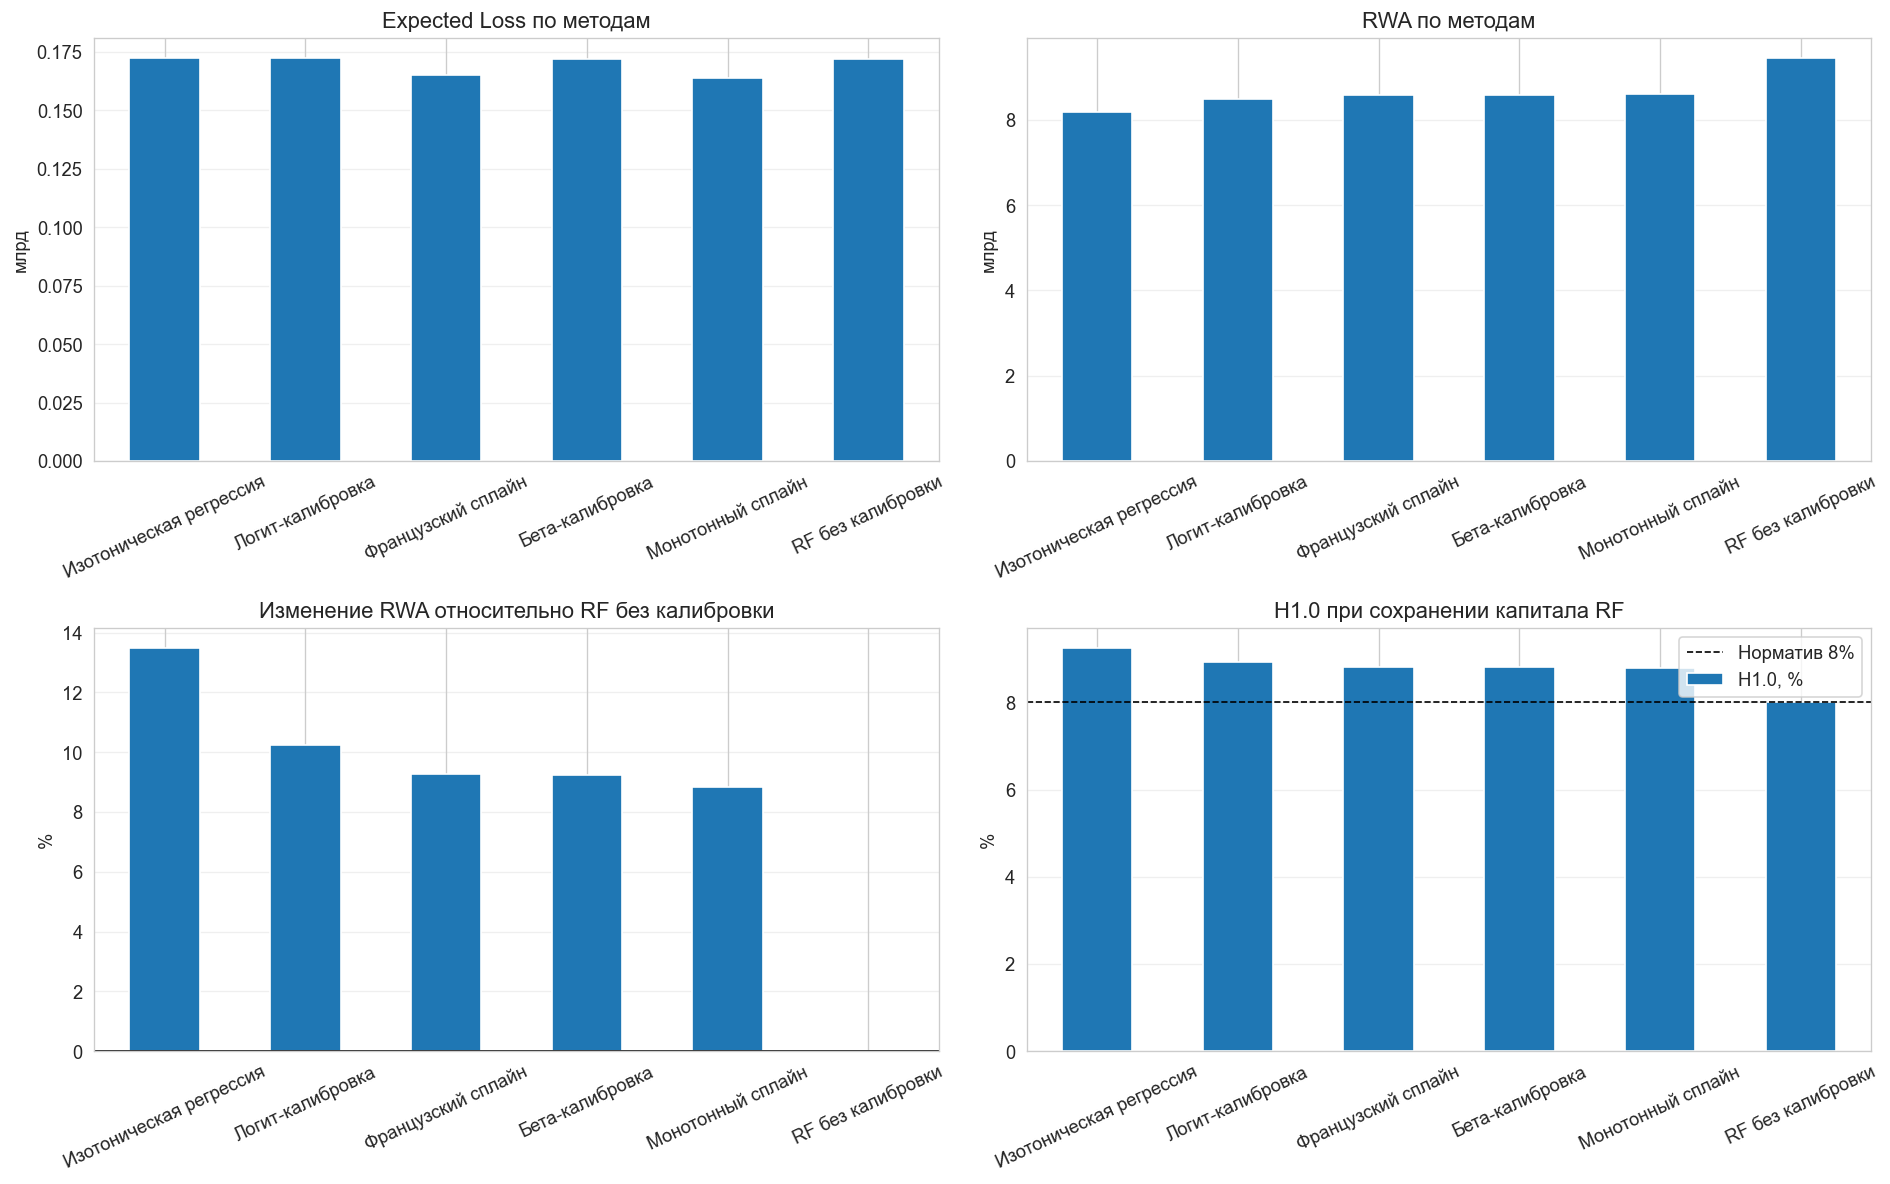

In [27]:
# =========================
# Компактная визуализация capital impact
# =========================

plot_df = df_rwa.reset_index().copy()

plot_df["EL, млрд"] = plot_df["total_expected_loss"] / 1_000_000_000
plot_df["RWA, млрд"] = plot_df["total_rwa"] / 1_000_000_000
plot_df["Изм. RWA vs RF, %"] = 100 * plot_df["rwa_saving_vs_baseline_pct"]
plot_df["Н1.0, %"] = 100 * plot_df["h1_0_if_keep_rf_capital"]

# Если хочешь дополнительно видеть риск-вес портфеля:
plot_df["RWA / EAD, %"] = 100 * (plot_df["total_rwa"] / plot_df["total_ead"])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Expected Loss
plot_df.plot(
    x="method",
    y="EL, млрд",
    kind="bar",
    ax=axes[0, 0],
    legend=False,
    rot=25,
    title="Expected Loss по методам"
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("млрд")
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. RWA
plot_df.plot(
    x="method",
    y="RWA, млрд",
    kind="bar",
    ax=axes[0, 1],
    legend=False,
    rot=25,
    title="RWA по методам"
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("млрд")
axes[0, 1].grid(axis="y", alpha=0.3)

# 3. Изменение RWA vs RF
plot_df.plot(
    x="method",
    y="Изм. RWA vs RF, %",
    kind="bar",
    ax=axes[1, 0],
    legend=False,
    rot=25,
    title="Изменение RWA относительно RF без калибровки"
)
axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("%")
axes[1, 0].grid(axis="y", alpha=0.3)

# 4. Н1.0 при сохранении капитала RF
plot_df.plot(
    x="method",
    y="Н1.0, %",
    kind="bar",
    ax=axes[1, 1],
    legend=False,
    rot=25,
    title="Н1.0 при сохранении капитала RF"
)
axes[1, 1].axhline(
    100 * capital_assumptions.capital_ratio,
    color="black",
    lw=1,
    linestyle="--",
    label="Норматив 8%"
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("%")
axes[1, 1].grid(axis="y", alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Вогнутая функция совокупного капитала под кредитный риск

В данном блоке для каждого метода калибровки строится зависимость между вероятностью дефолта `PD` и отношением капитала к `EAD`. Совокупный капитал разбивается на две части:

- `K_EL = EL / EAD` — ожидаемые потери как доля от экспозиции;
- `K_UL = UL capital / EAD` — капитал под неожиданные потери как доля от экспозиции.

Суммарная кривая `K_EL + K_UL` показывает, как изменение PD влияет на резервирование и капитальную нагрузку. Отдельные графики строятся по каждому методу калибровки, а общий график позволяет сопоставить итоговую капитальную кривую между методами.

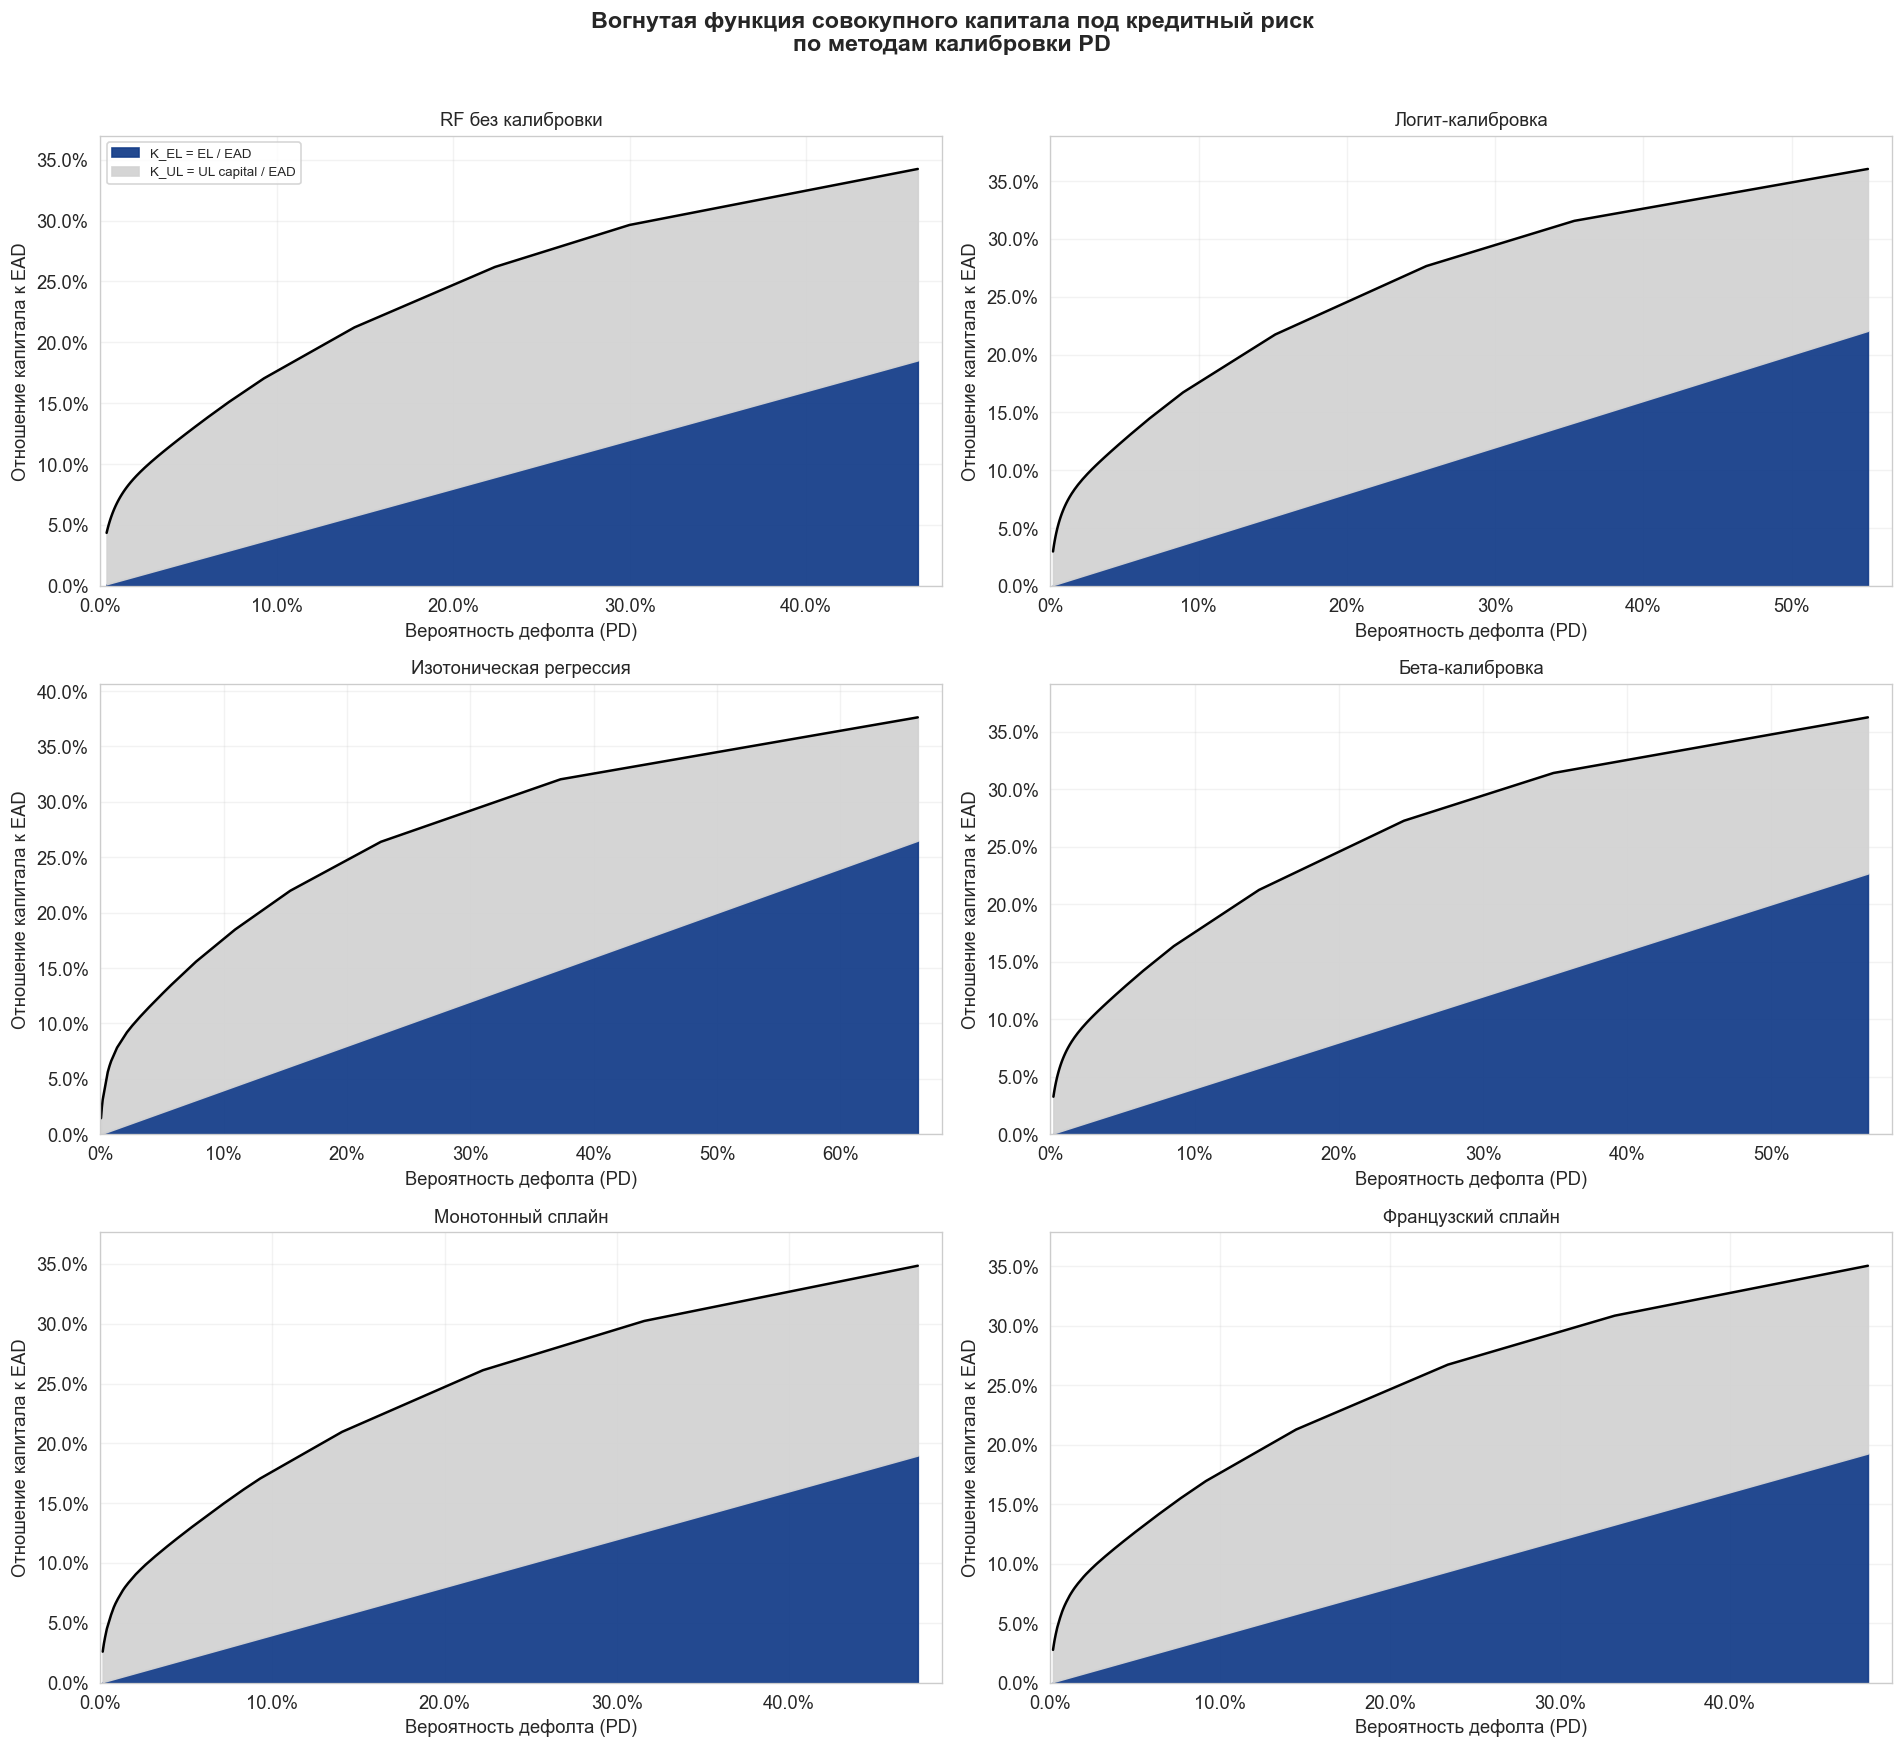

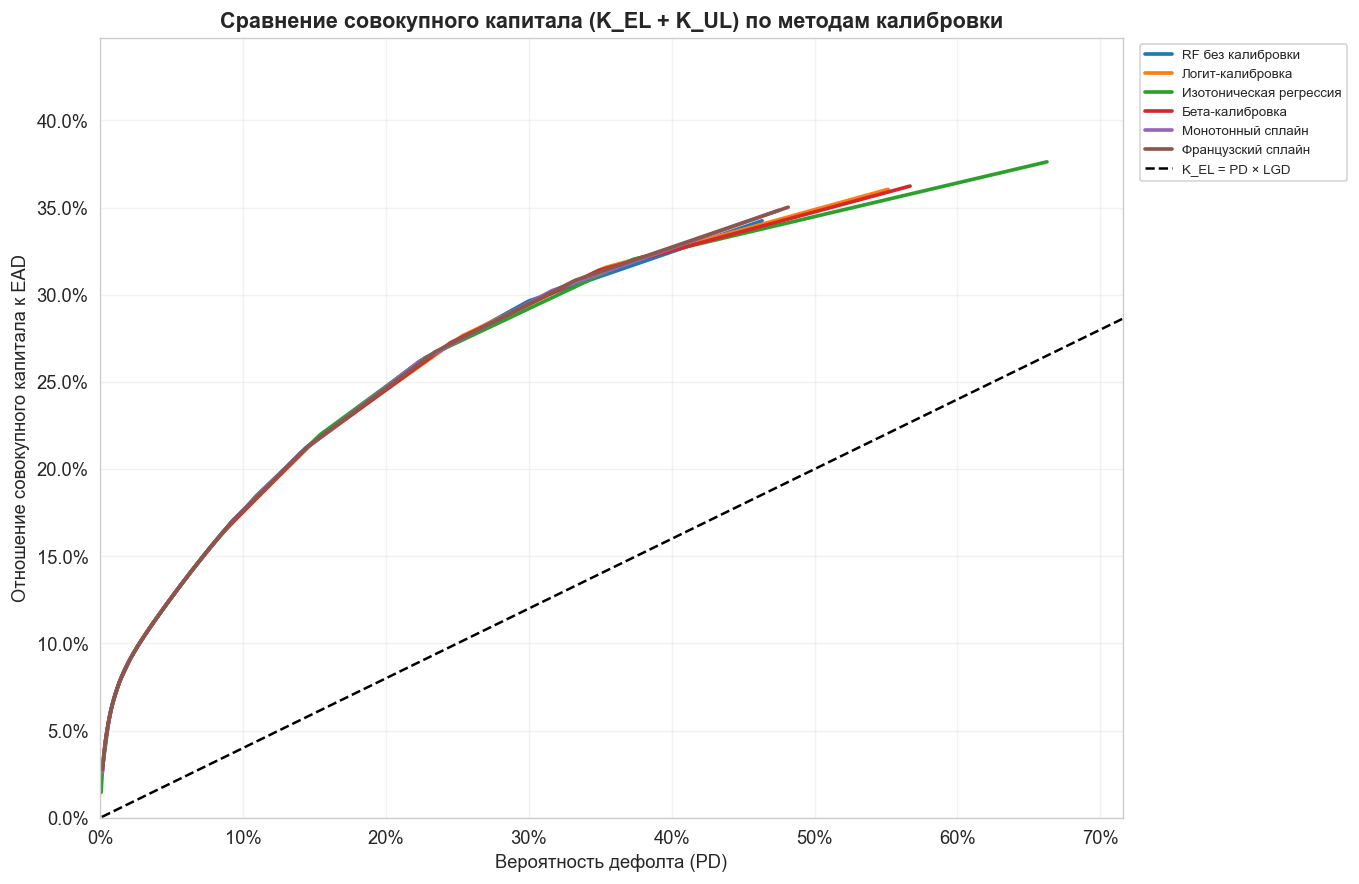

,avg_pd,avg_k_el_ratio,avg_k_ul_ratio,avg_k_total_ratio,max_pd
method,,,,,
RF без калибровки,4.90%,1.96%,8.62%,10.58%,86.79%
Логит-калибровка,4.91%,1.96%,7.73%,9.70%,93.53%
Изотоническая регрессия,4.91%,1.97%,7.45%,9.42%,100.00%
Бета-калибровка,4.90%,1.96%,7.82%,9.78%,96.61%
Монотонный сплайн,4.67%,1.87%,7.85%,9.72%,52.12%
Французский сплайн,4.70%,1.88%,7.82%,9.70%,51.89%


In [28]:
# =========================
# Вогнутая функция совокупного капитала под кредитный риск
# Для каждого метода калибровки + общий график
# =========================

capital_curve_methods = {
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

def build_capital_curve(pd_values, assumptions, n_bins=40):
    """
    Строит сглаженную эмпирическую кривую:
    PD -> K_EL/EAD, K_UL/EAD, K_total/EAD
    
    n_bins: число квантильных бинов для сглаживания.
    """
    pd_values = np.clip(np.asarray(pd_values, dtype=float), 1e-6, 1 - 1e-6)
    pd_values = np.sort(pd_values)

    tmp = calculate_irb_capital(pd_values, assumptions=assumptions).copy()
    tmp["k_el_ratio"] = tmp["expected_loss"] / tmp["ead"]
    tmp["k_ul_ratio"] = tmp["unexpected_loss_capital"] / tmp["ead"]
    tmp["k_total_ratio"] = tmp["k_el_ratio"] + tmp["k_ul_ratio"]

    # Сглаживание через квантильные бины
    if n_bins is not None and len(tmp) > n_bins:
        tmp["pd_bin"] = pd.qcut(tmp["pd"], q=n_bins, duplicates="drop")
        curve = (
            tmp.groupby("pd_bin", observed=True)
            .agg(
                pd=("pd", "mean"),
                k_el_ratio=("k_el_ratio", "mean"),
                k_ul_ratio=("k_ul_ratio", "mean"),
                k_total_ratio=("k_total_ratio", "mean"),
                n=("pd", "size"),
            )
            .reset_index(drop=True)
            .sort_values("pd")
        )
    else:
        curve = tmp[["pd", "k_el_ratio", "k_ul_ratio", "k_total_ratio"]].copy()

    return curve


# -------------------------
# 1. Индивидуальные графики для каждого метода
# -------------------------
n_methods = len(capital_curve_methods)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.8 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (method, probs) in enumerate(capital_curve_methods.items()):
    ax = axes[i]
    curve = build_capital_curve(probs, capital_assumptions, n_bins=40)

    # Нижняя часть: K_EL
    ax.fill_between(
        curve["pd"],
        0,
        curve["k_el_ratio"],
        color="#173f8a",
        alpha=0.95,
        label="K_EL = EL / EAD",
    )

    # Верхняя часть: K_UL
    ax.fill_between(
        curve["pd"],
        curve["k_el_ratio"],
        curve["k_total_ratio"],
        color="lightgray",
        alpha=0.95,
        label="K_UL = UL capital / EAD",
    )

    # Граница суммарного капитала
    ax.plot(
        curve["pd"],
        curve["k_total_ratio"],
        color="black",
        linewidth=1.5,
    )

    ax.set_title(method, fontsize=11)
    ax.set_xlabel("Вероятность дефолта (PD)")
    ax.set_ylabel("Отношение капитала к EAD")
    ax.set_xlim(0, min(1.0, curve["pd"].max() * 1.03))
    ax.set_ylim(0, max(0.35, curve["k_total_ratio"].max() * 1.08))
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(True, alpha=0.25)

    if i == 0:
        ax.legend(fontsize=8, loc="upper left")

# убрать пустые оси
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Вогнутая функция совокупного капитала под кредитный риск\n"
    "по методам калибровки PD",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()


# -------------------------
# 2. Общий график: сравнение суммарной кривой капитала
# -------------------------
capital_curves = {
    method: build_capital_curve(probs, capital_assumptions, n_bins=40)
    for method, probs in capital_curve_methods.items()
}

max_curve_pd = max(float(curve["pd"].max()) for curve in capital_curves.values())
max_curve_capital = max(float(curve["k_total_ratio"].max()) for curve in capital_curves.values())

pd_grid = np.linspace(0.001, max(0.999, max_curve_pd), 300)
k_el_grid = pd_grid * capital_assumptions.lgd
max_reference_capital = float(k_el_grid.max())

fig, ax = plt.subplots(figsize=(14, 7.5))

for method, curve in capital_curves.items():
    ax.plot(
        curve["pd"],
        curve["k_total_ratio"],
        linewidth=2.2,
        label=method,
    )

# Для ориентира: ожидаемые потери без UL capital. 
ax.plot(
    pd_grid,
    k_el_grid,
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="K_EL = PD × LGD",
)

ax.set_title(
    "Сравнение совокупного капитала (K_EL + K_UL) по методам калибровки",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Вероятность дефолта (PD)")
ax.set_ylabel("Отношение совокупного капитала к EAD")
ax.set_xlim(0, min(1.0, max_curve_pd * 1.08))
ax.set_ylim(0, max(max_curve_capital, max_reference_capital) * 1.12)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


# -------------------------
# 3. Таблица-резюме по среднему уровню капитала
# -------------------------
capital_curve_summary = []

for method, probs in capital_curve_methods.items():
    tmp = calculate_irb_capital(probs, assumptions=capital_assumptions).copy()

    capital_curve_summary.append({
        "method": method,
        "avg_pd": np.mean(tmp["pd"]),
        "avg_k_el_ratio": np.mean(tmp["expected_loss"] / tmp["ead"]),
        "avg_k_ul_ratio": np.mean(tmp["unexpected_loss_capital"] / tmp["ead"]),
        "avg_k_total_ratio": np.mean(
            (tmp["expected_loss"] + tmp["unexpected_loss_capital"]) / tmp["ead"]
        ),
        "max_pd": np.max(tmp["pd"]),
    })

capital_curve_summary = pd.DataFrame(capital_curve_summary).set_index("method")

display(
    capital_curve_summary.style.format({
        "avg_pd": "{:.2%}",
        "avg_k_el_ratio": "{:.2%}",
        "avg_k_ul_ratio": "{:.2%}",
        "avg_k_total_ratio": "{:.2%}",
        "max_pd": "{:.2%}",
    })
)